# Data Cleaning and Integration

This notebook is the authoritative, executable cleaning workflow. Each source section defines its actual transformations in Python, applies them to all downloaded years, inspects intermediate results and checks quality.

**Downstream dataset:** `analysis_county_year` contains validated features and migration measures, including flagged socioeconomic imputations fitted on 2009 to 2018 training data. Validation uses 2019 to 2020 and testing uses 2021 to 2023. Derived variables are recalculated after imputation. Migration outcomes, population and climate are never imputed.

The final export has no NA/NaN, blank missing markers, infinities, duplicate keys or violations of documented validity rules. Source audit tables preserve suppressed/unavailable values. Plausible statistical extremes remain flagged: an IQR outlier alone is not evidence of an error, and validation cannot certify every publisher measurement.


## 1. Set up the workflow and shared conventions

First configure the environment and study period, then define the shared readers and audit helpers used by the source sections.


### 1.1. Initialize the environment and study settings

Import the required libraries, configure output directories and displays, and set the study years, training cutoff and geographic constants.


In [114]:
from pathlib import Path
import sys, json, hashlib, io, re, zipfile, unicodedata
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/us_migration').is_dir())
sys.path.insert(0,str(ROOT/'src'))
from us_migration.acquisition import ACS_VARIABLES
from us_migration.eda import FEATURES, OUTCOMES, profile
from us_migration.notebook_helpers import raw_snapshot, comparison_image, table_image
DATA=ROOT/'data/processed'; TABLES=ROOT/'reports/tables'


In [115]:
DATA=ROOT/'data/processed'; TABLES=ROOT/'reports/tables'
DATA.mkdir(parents=True,exist_ok=True); TABLES.mkdir(parents=True,exist_ok=True)
DATA.mkdir(parents=True,exist_ok=True); TABLES.mkdir(parents=True,exist_ok=True)
plt.style.use('dark_background')
plt.rcParams.update({'figure.facecolor':'#1e1e1e','axes.facecolor':'#252526','savefig.facecolor':'#1e1e1e'})
pd.set_option('display.max_columns',14)


In [ ]:
START_YEAR=2009
END_YEAR=2026
# Fit imputations on training data; apply frozen estimates across all splits.
TRAIN_END=2018
VALIDATION_END=2020
SMALL_MISSING_FRACTION=.05
# Take the following states as geographical units due to county boundary changes over period
STATE_UNITS={'02':'Alaska','09':'Connecticut'}
MEASURES=FEATURES+['inflow_individuals','outflow_individuals','net_individuals']+OUTCOMES
KEYS=['county_fips','year']
IDENTIFIERS=['county_fips','county_name','year']
POSITIVE=['population','median_household_income','median_home_value','median_gross_rent']
PERCENTAGES=['poverty_pct','unemployment_pct','vacancy_pct','homeownership_pct','bachelors_plus_pct']

In [117]:
US_STATES = set('01 02 04 05 06 08 09 10 11 12 13 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 50 51 53 54 55 56'.split())
NOAA_STATE_FIPS = dict(zip([f'{i:02}' for i in range(1,51)],
    '01 04 05 06 08 09 10 12 13 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 50 51 53 54 55 56 15 02'.split()))

### 1.2. Read the snapshot catalog and define audit helpers

The environment and study period are now configured. Read the catalog to see which originals are available, then define shared saving and quality-report helpers. Snapshots are checksum-verified when loaded. IRS years identify interval-ending years, ACS years identify five-year windows, FEMA uses incident start year, and NOAA uses calendar year.


In [118]:
catalog=json.loads((ROOT/'data/raw/catalog.json').read_text())
provenance=[]; inventory=[]
records=pd.DataFrame(catalog.values());records['source']=records.logical_id.str.split('/').str[0]
display(records.groupby('source').agg(files=('sha256','size'),bytes=('bytes','sum')))

def save_table(name,frame,keys):
    if keys and frame.duplicated(keys).any(): raise ValueError(f'{name}: duplicate keys')
    frame.to_parquet(DATA/(name+'.parquet'),index=False)
    inventory.append({'table':name,'rows':len(frame),'columns':len(frame.columns),
        'duplicate_keys':int(frame.duplicated(keys).sum()) if keys else None,
        'min_year':int(frame.year.min()) if 'year' in frame and frame.year.notna().any() else None,
        'max_year':int(frame.year.max()) if 'year' in frame and frame.year.notna().any() else None})

,files,bytes
source,,
acs,32,157169760
acs_flows,329,812887697
acs_state_flows,4,8751727
acs_states,16,245463
fema,2,24967804
geography,1,470618
irs,52,162612138
irs_states,10,1005071
noaa,7,163774217


### 1.3. Define source-quality reporting

Use one diagnostic format across sources to summarize missingness, distributions and duplicate keys. Source audits may retain unavailable measurements; final completeness is enforced after joining and imputation.


In [119]:
def source_quality(frame, measures, keys):
    values=frame[measures].apply(pd.to_numeric,errors='coerce')
    display(profile(frame,measures)[['variable','dtype','missing','missing_pct','minimum','median','maximum','iqr_outliers']])
    text=frame.select_dtypes(include=['object','string']).astype('string')
    markers=text.apply(lambda s:s.str.strip().str.lower().isin(['','na','n/a','nan','null','none','<na>']))
    display(pd.Series({'rows':len(frame),'duplicate_keys':int(frame.duplicated(keys).sum()),
        'missing_measurements':int(values.isna().sum().sum()),
        'infinite_measurements':int(np.isinf(values).sum().sum()),
        'blank_or_missing_text_markers':int(markers.sum().sum())}).to_frame('count'))
    assert not frame.duplicated(keys).any()
    assert not np.isinf(values).any().any()


### 1.4. Define geographic-code formatting

Before cleaning any source, define how geographic codes are represented. Keep FIPS as strings and preserve leading zeros so later joins use consistent identifiers.


In [120]:
def code(series, width):
    return series.astype('string').str.strip().str.replace(r'\.0$','',regex=True).str.zfill(width)

### 1.5. Define numeric parsing

With identifier formatting established, define numeric conversion separately. Remove formatting such as commas and convert unparseable values to missing; source-specific rules below decide which numeric codes also mean missing.


In [121]:
def numeric(series):
    return pd.to_numeric(series.astype('string').str.replace(',','',regex=False).str.strip(),errors='coerce').astype(float)

### 1.6. Define Census response loading

Finally, define how a Census JSON response becomes a table. The next section uses this loader and the shared formatting functions on an actual ACS snapshot.


In [122]:
def api_frame(path):
    rows = json.loads(path.read_bytes())
    if not isinstance(rows,list) or len(rows)<2:
        raise ValueError('Expected Census header and data rows')
    return pd.DataFrame(rows[1:],columns=rows[0])

## 2. ACS characteristics: inspect special codes, retain uncertainty, derive percentages

### 2.1. Load the latest ACS snapshot and identify special codes

The inspection of one original county snapshot is provided here as an example. Preview the three money variables and count missing values and negative special codes; later steps apply the same rules to every downloaded vintage.


In [123]:
acs_year=max(int(k.split('/')[1]) for k in catalog if k.startswith('acs/') and k.endswith('/counties'))
acs_path,_=raw_snapshot(f'acs/{acs_year}/counties')
raw_acs=api_frame(acs_path)
money_codes=['B19013_001E','B25077_001E','B25064_001E']
display(raw_acs[['NAME','state','county']+money_codes].head())
money=raw_acs[money_codes].apply(pd.to_numeric,errors='coerce')
display(pd.DataFrame({'missing':money.isna().sum(),'negative_special_codes':money.lt(0).sum()}))

,NAME,state,county,B19013_001E,B25077_001E,B25064_001E
0,"Autauga County, Alabama",01,001,72481,207200,1263
1,"Baldwin County, Alabama",01,003,78775,316900,1277
2,"Barbour County, Alabama",01,005,46042,112900,688
3,"Bibb County, Alabama",01,007,52541,145700,733
4,"Blount County, Alabama",01,009,64190,175200,776


,missing,negative_special_codes
B19013_001E,0,1
B25077_001E,0,5
B25064_001E,0,7


### 2.2. Define the ACS special-value rule

The preceding counts identify numeric values that represent unavailable estimates. Here they are treated as missing values. Selected ACS measures are nonnegative, so negative special codes must not enter arithmetic. This cell defines the rule; the example execution below applies it.


In [124]:
def acs_numeric(series):
    values = numeric(series)
    # All selected ACS measures are nonnegative; negative values are API special codes.
    return values.mask(values < 0)

### 2.3. Define identifiers, estimates and derived percentages

Build three small functions in processing order: create identifiers, convert estimates and margins of error with flags, then calculate percentages. The final wrapper combines these functions. These cells define the transformations; the following step executes them.


**Transformation: Preserve zero-padded identifiers and the five-year reference window.**


In [125]:
def acs_identifiers(raw, year):
    frame = pd.DataFrame({'county_fips':code(raw['state'],2)+code(raw.get('county',pd.Series('000',index=raw.index)),3),
        'county_name':raw['NAME'],'year':year,'period_start':year-4,'period_end':year})
    frame['in_scope_us'] = frame.county_fips.str[:2].isin(US_STATES)
    return frame


**Transformation: Convert estimates and margins of error, recording unavailable values.**


In [126]:
def acs_estimates(raw, frame):
    for variable,name in ACS_VARIABLES.items():
        for suffix,label in [('E',name),('M',name+'_moe')]:
            values = raw.get(variable+suffix,pd.Series(pd.NA,index=raw.index))
            frame[label] = acs_numeric(values)
            frame[label+'_flag'] = np.where(values.isna(),'not_available',np.where(numeric(values)<0,'special_value',''))
    return frame


**Transformation: Divide by the correct positive universe; require all degree components.**


In [127]:
def acs_percentages(frame):
    for target,numerator,denominator in [
        ('poverty_pct','below_poverty','poverty_universe'),
        ('unemployment_pct','unemployed','civilian_labor_force'),
        ('vacancy_pct','vacant_units','housing_units'),
        ('homeownership_pct','owner_occupied_units','occupied_units')]:
        frame[target] = 100*frame[numerator]/frame[denominator].where(frame[denominator]>0)
    degree_cols = ['bachelors','masters','professional_degree','doctorate']
    frame['bachelors_plus_pct'] = 100*frame[degree_cols].sum(axis=1,min_count=4)/frame.population_25_plus.where(frame.population_25_plus>0)
    return frame


The wrapper below combines the functions just defined in execution order. It defines the reusable recipe; the following example calls run it on data.


In [128]:
def clean_acs(path,year):
    raw=api_frame(path)
    frame=acs_identifiers(raw,year)
    frame=acs_estimates(raw,frame)
    return acs_percentages(frame)


### 2.4. Apply the transformations to the example snapshot

Now run the three functions in order on the loaded ACS snapshot. Inspect the output after each call, then confirm that this step-by-step result matches the combined cleaning function used for the full run.


In [129]:
acs_example=acs_identifiers(raw_acs,acs_year)
display(acs_example.head(4))


,county_fips,county_name,year,period_start,period_end,in_scope_us
0,01001,"Autauga County, Alabama",2024,2020,2024,True
1,01003,"Baldwin County, Alabama",2024,2020,2024,True
2,01005,"Barbour County, Alabama",2024,2020,2024,True
3,01007,"Bibb County, Alabama",2024,2020,2024,True


In [130]:
acs_example=acs_estimates(raw_acs,acs_example)
display(acs_example[['county_name','median_household_income','median_household_income_flag']].head(6))


,county_name,median_household_income,median_household_income_flag
0,"Autauga County, Alabama",72481.0,
1,"Baldwin County, Alabama",78775.0,
2,"Barbour County, Alabama",46042.0,
3,"Bibb County, Alabama",52541.0,
4,"Blount County, Alabama",64190.0,
5,"Bullock County, Alabama",31310.0,


In [131]:
acs_example=acs_percentages(acs_example)
pd.testing.assert_frame_equal(acs_example,clean_acs(acs_path,acs_year))
display(acs_example[['county_name','poverty_pct','bachelors_plus_pct']].head(6))


,county_name,poverty_pct,bachelors_plus_pct
0,"Autauga County, Alabama",11.289509,29.138481
1,"Baldwin County, Alabama",10.092700,33.689508
2,"Barbour County, Alabama",21.382570,10.627306
3,"Bibb County, Alabama",22.457048,11.725650
4,"Blount County, Alabama",12.860103,15.818235
5,"Bullock County, Alabama",33.272248,8.116660


### 2.5. Validate the example and compare raw and cleaned values

Check the changes before scaling up. The preview selects records with a problem in any money variable but displays income only, so some income values remain unchanged. Special codes become flagged missing values in the source table; socioeconomic imputation follows the join in section 9.


In [132]:
acs_before_after=pd.DataFrame({'raw_income':raw_acs.B19013_001E,
 'clean_income':acs_example.median_household_income,'reason':acs_example.median_household_income_flag})
display(acs_before_after.loc[money.lt(0).any(axis=1)].head(6))
assert acs_example.median_household_income.dropna().ge(0).all()


,raw_income,clean_income,reason
188,105521,105521.0,
232,63355,63355.0,
550,73750,73750.0,
1803,-666666666,NaN,special_value
2541,65625,65625.0,
2577,81022,81022.0,


### 2.6. Clean every county vintage and review source-wide quality

Having checked the worked example, apply the same function to all available county snapshots within the configured period. Attach each snapshot hash, combine the vintages, and inspect missingness, distributions and duplicate keys. Empty audit flags mean no issue; the generic text-marker count includes those intentional blanks.


In [133]:
frames=[]
for logical,record in sorted(catalog.items()):
    parts=logical.split('/')
    if parts[0]=='acs' and parts[-1]=='counties':
        year=int(parts[1]) if parts[1].isdigit() else None
        if year is not None and not START_YEAR<=year<=END_YEAR: continue
        path,_=raw_snapshot(logical)
        frame=clean_acs(path,year)
        frame['source_snapshot']=record['sha256']
        frames.append(frame)
        provenance.append(record)
acs=pd.concat(frames,ignore_index=True)
display(acs.head(4))


,county_fips,county_name,year,period_start,period_end,in_scope_us,population,...,doctorate_moe_flag,poverty_pct,unemployment_pct,vacancy_pct,homeownership_pct,bachelors_plus_pct,source_snapshot
0,13091,"Dodge County, Georgia",2009,2005,2009,True,19695.0,...,not_available,22.319334,NaN,18.553311,69.780854,NaN,947024dd9f24dc1ae5a6ad93bd56e06204e2ef2bb49262...
1,13093,"Dooly County, Georgia",2009,2005,2009,True,11641.0,...,not_available,27.475248,NaN,17.965368,66.068602,NaN,947024dd9f24dc1ae5a6ad93bd56e06204e2ef2bb49262...
2,13095,"Dougherty County, Georgia",2009,2005,2009,True,95330.0,...,not_available,25.241098,NaN,11.697578,49.424568,NaN,947024dd9f24dc1ae5a6ad93bd56e06204e2ef2bb49262...
3,13097,"Douglas County, Georgia",2009,2005,2009,True,122657.0,...,not_available,10.909719,NaN,11.193218,70.673927,NaN,947024dd9f24dc1ae5a6ad93bd56e06204e2ef2bb49262...


In [134]:
print('acs:',f'{len(acs):,} records')


acs: 51,533 records


In [135]:
source_quality(acs,['population','median_household_income','poverty_pct','bachelors_plus_pct'],KEYS)
assert acs.county_fips.str.fullmatch(r'\d{5}').all()


,variable,dtype,missing,missing_pct,minimum,median,maximum,iqr_outliers
0,population,float64,0,0.000000,33.0,25986.000000,1.010572e+07,6950
1,median_household_income,float64,8,0.015524,10499.0,48750.000000,1.817650e+05,1655
2,poverty_pct,float64,1,0.001941,0.0,14.824552,6.707371e+01,2178
3,bachelors_plus_pct,float64,9663,18.751092,0.0,19.494737,8.053254e+01,1889


,count
rows,51533
duplicate_keys,0
missing_measurements,9672
infinite_measurements,0
blank_or_missing_text_markers,1684688


### 2.7. Save county features and geographic vintages

The combined county table has passed its structural checks. Save its estimates, uncertainty and flags, plus a separate geographic reference. These are source tables; remaining missing values are handled during the later joined-data workflow.


In [136]:
save_table('county_features',acs,['county_fips','year'])
geography=acs[['county_fips','county_name','year','in_scope_us']].copy()
save_table('county_geography_vintages',geography,['county_fips','year'])
display(profile(acs,['population','median_household_income','poverty_pct','bachelors_plus_pct']))

,variable,dtype,rows,missing,missing_pct,unique,zeros,...,minimum,p01,median,p99,maximum,skew,iqr_outliers
0,population,float64,51533,0,0.000000,39253,0,...,33.0,924.960000,25986.000000,1.238305e+06,1.010572e+07,13.993944,6950
1,median_household_income,float64,51533,8,0.015524,32425,0,...,10499.0,17193.400000,48750.000000,1.044776e+05,1.817650e+05,1.128216,1655
2,poverty_pct,float64,51533,1,0.001941,51305,7,...,0.0,4.814343,14.824552,5.060163e+01,6.707371e+01,2.005008,2178
3,bachelors_plus_pct,float64,51533,9663,18.751092,41629,7,...,0.0,8.366843,19.494737,5.414860e+01,8.053254e+01,1.428925,1889


### 2.8. Process and save the Alaska and Connecticut state supplements

County features are saved. Now reuse the same cleaning stages for the state snapshots, retain Alaska and Connecticut for their later state-level treatment, and save the state feature table. The printed state-row count precedes that filtering. The final comparison image uses the original county example.


In [137]:
frames=[]
for logical,record in sorted(catalog.items()):
    parts=logical.split('/')
    if parts[0]=='acs_states':
        year=int(parts[1]) if parts[1].isdigit() else None
        if year is not None and not START_YEAR<=year<=END_YEAR: continue
        path,_=raw_snapshot(logical)
        frame=clean_acs(path,year)
        frame['source_snapshot']=record['sha256']
        frames.append(frame)
        provenance.append(record)
states=pd.concat(frames,ignore_index=True)
display(states.head(4))


,county_fips,county_name,year,period_start,period_end,in_scope_us,population,...,doctorate_moe_flag,poverty_pct,unemployment_pct,vacancy_pct,homeownership_pct,bachelors_plus_pct,source_snapshot
0,01000,Alabama,2009,2005,2009,True,4633360.0,...,not_available,16.792561,NaN,14.978201,70.759755,NaN,6d6ab78e844cfc7278c0c18e297861ac0fe00c5e90ccee...
1,02000,Alaska,2009,2005,2009,True,683142.0,...,not_available,9.614464,NaN,16.206020,63.750165,NaN,6d6ab78e844cfc7278c0c18e297861ac0fe00c5e90ccee...
2,04000,Arizona,2009,2005,2009,True,6324865.0,...,not_available,14.730784,NaN,15.404446,68.291900,NaN,6d6ab78e844cfc7278c0c18e297861ac0fe00c5e90ccee...
3,05000,Arkansas,2009,2005,2009,True,2838143.0,...,not_available,17.737473,NaN,13.763585,67.543922,NaN,6d6ab78e844cfc7278c0c18e297861ac0fe00c5e90ccee...


In [138]:
print('states:',f'{len(states):,} records')


states: 832 records


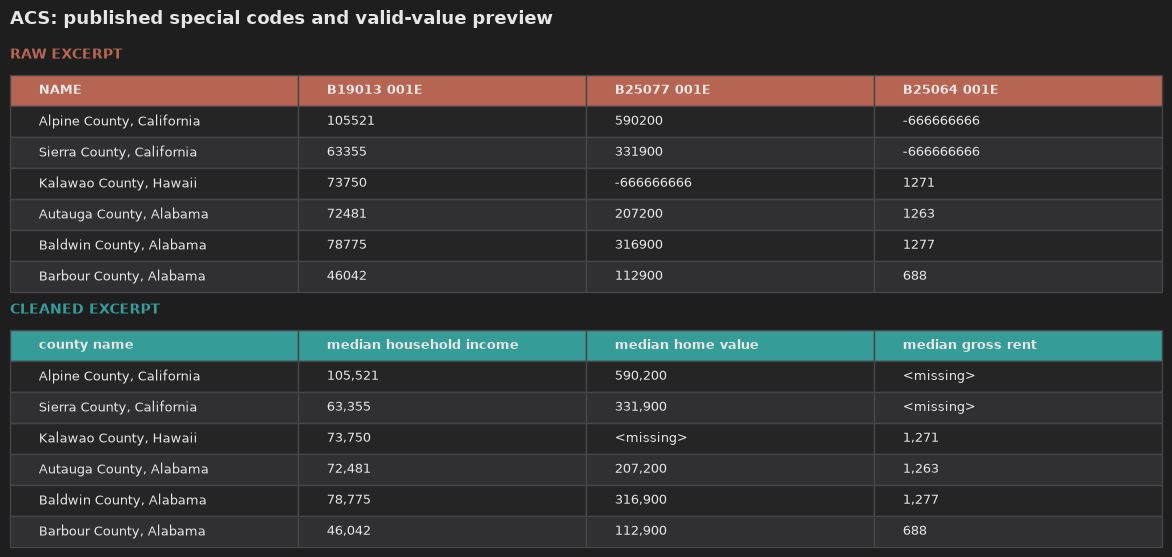

WindowsPath('C:/Users/kenny/Data Science Projects/us-migration/reports/figures/cleaning/01_acs_raw_vs_clean.png')

In [139]:
states=states.loc[states.county_fips.str[:2].isin(STATE_UNITS)].copy()
save_table('state_features',states,KEYS)
bad=money.lt(0).any(axis=1)|money.isna().any(axis=1)
ids=list(raw_acs.index[bad][:3])+list(raw_acs.index[~bad][:3])
cleaned_acs=clean_acs(acs_path,acs_year)
comparison_image(raw_acs.loc[ids,['NAME']+money_codes],
 cleaned_acs.loc[ids,['county_name','median_household_income','median_home_value','median_gross_rent']],
 'ACS: published special codes and valid-value preview','01_acs_raw_vs_clean.png')

## 3. IRS: preserve directions, suppression and totals; reject conflicting pairs

### 3.1. Load an IRS CSV and inspect published values

Start with a modern raw CSV and inspect missing or negative measurements. This compact example introduces the cleaning rules; a later reader applies the same rules to historical workbook layouts.


In [140]:
irs_logical=max(k for k in catalog if k.startswith('irs/') and k.endswith('/inflow'))
irs_example_year=int(irs_logical.split('/')[1])
irs_path,_=raw_snapshot(irs_logical)
try: raw_irs=pd.read_csv(irs_path,dtype=str,encoding='utf-8-sig')
except UnicodeDecodeError: raw_irs=pd.read_csv(irs_path,dtype=str,encoding='cp1252')
display(raw_irs.head(6))
irs_raw_numbers=raw_irs.iloc[:,-3:].apply(numeric)
display(pd.DataFrame({'missing':irs_raw_numbers.isna().sum(),'negative_values':irs_raw_numbers.lt(0).sum()}))


,y2_statefips,y2_countyfips,y1_statefips,y1_countyfips,y1_state,y1_countyname,n1,n2,agi
0,01,001,96,000,AL,Autauga County Total Migration-US and Foreign,2148,4413,138794
1,01,001,97,000,AL,Autauga County Total Migration-US,2120,4345,135795
2,01,001,97,001,AL,Autauga County Total Migration-Same State,1357,2588,77614
3,01,001,97,003,AL,Autauga County Total Migration-Different State,763,1757,58181
4,01,001,98,000,AL,Autauga County Total Migration-Foreign,28,68,2998
5,01,001,01,001,AL,Autauga County Non-migrants,20045,43150,1531683


,missing,negative_values
n1,0,5818
n2,0,5818
agi,0,5818


### 3.2. Define IRS layout, geography, measurement and direction rules

The transformations are run in the following order: Remove embedded headers, construct geographic identifiers, mask suppression markers, then classify and orient flows. Negative AGI can be legitimate; inflow and outflow views describe the same movement and must not be added together.


**Transformation: Check the nine-column layout and remove embedded non-data headers.**


In [141]:
def irs_layout(raw):
    if raw.shape[1] != 9:
        raise ValueError(f'Unexpected IRS width: {raw.shape[1]}')
    raw = raw.copy()
    raw.columns = ['ref_state','ref_county','other_state','other_county','other_state_name','other_name','returns','individuals','agi_thousands']
    # Legacy workbooks contain notes/headers; data rows have numeric geographic codes.
    valid = numeric(raw.ref_state).notna() & numeric(raw.ref_county).notna()
    raw = raw.loc[valid].copy()
    return raw


**Transformation: Keep leading zeros while constructing reference and counterpart FIPS.**


In [142]:
def irs_geography(raw):
    for col,width in [('ref_state',2),('ref_county',3),('other_state',2),('other_county',3)]:
        raw[col] = code(raw[col],width)
    raw['county_fips'] = raw.ref_state+raw.ref_county
    raw['other_fips'] = raw.other_state+raw.other_county
    return raw


**Transformation: Mask suppression markers; preserve legitimate negative AGI.**


In [143]:
def irs_measures(raw):
    for col in ['returns','individuals','agi_thousands']:
        values = numeric(raw[col])
        # AGI may legitimately be negative; only -1 is the documented numeric suppression marker.
        missing = values.eq(-1) if col=='agi_thousands' else values.lt(0)
        raw[col+'_suppressed_or_missing'] = missing | values.isna()
        raw[col] = values.mask(missing)
    return raw


**Transformation: Separate totals, nonmigrants and county pairs; orient origin and destination.**


In [144]:
def irs_classify(raw, year, view):
    domestic = raw.ref_state.isin(US_STATES) & raw.other_state.isin(US_STATES) & raw.ref_county.ne('000') & raw.other_county.ne('000')
    raw['row_type'] = np.select([
        raw.ref_county.eq('000'), domestic & raw.county_fips.eq(raw.other_fips),
        domestic, raw.other_state.eq('97') & raw.other_county.eq('000'),
        raw.other_state.eq('96') & raw.other_county.eq('000'),
    ],['state_summary','nonmigrant','county_pair','domestic_total','all_migration_total'],default='other_or_foreign')
    raw['origin_fips'] = raw.other_fips if view=='inflow' else raw.county_fips
    raw['destination_fips'] = raw.county_fips if view=='inflow' else raw.other_fips
    raw['view'] = view
    raw['year'] = year
    raw['period_start'] = year-1
    raw['methodology_series'] = 'pre_2012' if year<2012 else ('2012_2022' if year<2023 else '2023_onward')
    return raw


The wrapper below combines the functions just defined in execution order. It defines the reusable recipe; the following example calls run it on data.


In [145]:
def normalize_irs(raw,year,view):
    raw=irs_layout(raw)
    raw=irs_geography(raw)
    raw=irs_measures(raw)
    return irs_classify(raw,year,view)


### 3.3. Apply the IRS rules to the example

Execute the functions just defined and inspect each intermediate result. Confirm that the individual calls match the combined normalizer before extending the process to historical files.


In [146]:
irs_example=irs_layout(raw_irs)
print('Embedded header/note rows removed:',len(raw_irs)-len(irs_example))
irs_example=irs_geography(irs_example)
display(irs_example[['county_fips','other_fips']].head())


Embedded header/note rows removed: 0


,county_fips,other_fips
0,01001,96000
1,01001,97000
2,01001,97001
3,01001,97003
4,01001,98000


In [147]:
irs_example=irs_measures(irs_example)
display(irs_example[['returns','individuals','agi_thousands','individuals_suppressed_or_missing']].head())


,returns,individuals,agi_thousands,individuals_suppressed_or_missing
0,2148.0,4413.0,138794.0,False
1,2120.0,4345.0,135795.0,False
2,1357.0,2588.0,77614.0,False
3,763.0,1757.0,58181.0,False
4,28.0,68.0,2998.0,False


In [148]:
irs_example=irs_classify(irs_example,irs_example_year,'inflow')
display(irs_example.row_type.value_counts().to_frame('rows'))
pd.testing.assert_frame_equal(irs_example,normalize_irs(raw_irs,irs_example_year,'inflow'))


,rows
row_type,
county_pair,53614
other_or_foreign,27099
nonmigrant,3143
all_migration_total,3096
domestic_total,3096


### 3.4. Define a reader for historical workbooks and modern CSVs

The example validated the normalization rules. This reader now connects different original file formats to that same normalizer and preserves workbook-member provenance.


In [149]:
def read_irs(path,year,view=None):
    if view:
        try:
            raw=pd.read_csv(path,dtype=str,encoding='utf-8-sig')
        except UnicodeDecodeError:
            raw=pd.read_csv(path,dtype=str,encoding='cp1252')
        return normalize_irs(raw,year,view)
    frames=[]
    with zipfile.ZipFile(path) as archive:
        for member in archive.namelist():
            match = re.search(r'co\d{4}([io])[^/]*\.xls[x]?$',member,re.I)
            if not match:
                continue
            workbook = pd.read_excel(io.BytesIO(archive.read(member)),header=None,sheet_name=None,dtype=str)
            for sheet,raw in workbook.items():
                if raw.empty:
                    continue
                # Data sheets have the nine-column published layout.
                if raw.shape[1]==9:
                    cleaned = normalize_irs(raw,year,'inflow' if match[1].lower()=='i' else 'outflow')
                    cleaned['archive_member'] = member+'::'+sheet
                    frames.append(cleaned)
    if not frames:
        raise ValueError('No recognized legacy IRS data sheets')
    return pd.concat(frames,ignore_index=True)

### 3.5. Define duplicate and conflict handling

Before combining published flows, deduplicate repeated pairs by collapsing identical measurements. The rule is applied when the full tables are saved below.


In [150]:
def canonical_irs_pairs(records):
    """Collapse repeated numeric records, but fail on conflicting published pair values."""
    keys=['year','view','origin_fips','destination_fips']
    pairs=records.loc[records.row_type.eq('county_pair')].copy()
    pairs=pairs.drop_duplicates(keys+['returns','individuals','agi_thousands'])
    if pairs.duplicated(keys).any():
        raise ValueError('Conflicting IRS pair records require investigation; no arbitrary selection made')
    return pairs

### 3.6. Define selection of interstate state totals

State supplements need an additional rule: code 97 is reused for US and same-state totals. Match both code and label so Alaska and Connecticut receive one interstate total per year and direction.


In [151]:
def normalize_state_irs(raw, year, view):
    """Code 97 is reused for US interstate and same-state totals; match the label."""
    raw=raw.copy()
    raw.columns=['ref_state','other_state','state_name','name','returns','individuals','agi_thousands']
    expanded=raw.assign(ref_county='000',other_county='000')[['ref_state','ref_county','other_state','other_county','state_name','name','returns','individuals','agi_thousands']]
    values=normalize_irs(expanded,year,view)
    interstate=values.other_name.str.strip().str.fullmatch(r'.*Total Migration\s*-\s*US',case=False,na=False)
    values=values.loc[values.county_fips.isin(['02000','09000'])&values.other_fips.eq('97000')&interstate].copy()
    values['row_type']='domestic_total'
    if values.duplicated(['county_fips','year','view']).any():
        raise ValueError('Duplicate published interstate totals')
    return values

### 3.7. Clean and combine all county IRS snapshots

The format, duplicate and state-total rules are defined. Read every available county vintage with the shared normalizer, attach source hashes and combine the records for validation.


In [152]:
frames=[]
for logical,record in sorted(catalog.items()):
    parts=logical.split('/')
    if parts[0]=='irs' and parts[-1] in ['legacy','inflow','outflow']:
        year=int(parts[1]) if parts[1].isdigit() else None
        if year is not None and not START_YEAR<=year<=END_YEAR: continue
        path,_=raw_snapshot(logical)
        frame=read_irs(path,year,None if parts[-1]=='legacy' else parts[-1])
        frame['source_snapshot']=record['sha256']
        frames.append(frame)
        provenance.append(record)
irs=pd.concat(frames,ignore_index=True)
display(irs.head(4))


,ref_state,ref_county,other_state,other_county,other_state_name,other_name,returns,...,destination_fips,view,year,period_start,methodology_series,archive_member,source_snapshot
0,02,000,96,000,AK,Total Mig - US & For,23408.0,...,02000,inflow,2009,2008,pre_2012,co0809iAk.xls::shell,56299c47411ba3e3e13d25de9c36daaf29daa1e810eb1a...
1,02,000,97,000,AK,Total Mig - US,22782.0,...,02000,inflow,2009,2008,pre_2012,co0809iAk.xls::shell,56299c47411ba3e3e13d25de9c36daaf29daa1e810eb1a...
2,02,000,97,001,AK,Total Mig - US Same St,7206.0,...,02000,inflow,2009,2008,pre_2012,co0809iAk.xls::shell,56299c47411ba3e3e13d25de9c36daaf29daa1e810eb1a...
3,02,000,97,003,AK,Total Mig - US Diff St,15576.0,...,02000,inflow,2009,2008,pre_2012,co0809iAk.xls::shell,56299c47411ba3e3e13d25de9c36daaf29daa1e810eb1a...


In [153]:
print('irs:',f'{len(irs):,} records')


irs: 2,957,793 records


### 3.8. Validate the combined IRS records

Inspect suppression across all vintages and assert that nonmissing household and individual counts are nonnegative. The raw-versus-cleaned preview shows which example measurements were masked; published missing outcomes remain missing.


In [154]:
display(irs.groupby('year')[['returns_suppressed_or_missing','individuals_suppressed_or_missing']].sum())
assert irs.individuals.dropna().ge(0).all()
assert irs.returns.dropna().ge(0).all()
irs_comparison=pd.DataFrame({'raw_individuals':raw_irs.iloc[:,7],
 'clean_individuals':irs_example.individuals,'suppressed_or_missing':irs_example.individuals_suppressed_or_missing})
display(irs_comparison.loc[irs_comparison.suppressed_or_missing.fillna(False)].head(6))


,returns_suppressed_or_missing,individuals_suppressed_or_missing
year,,
2009,4804,4804
2010,5013,5013
2011,4971,4971
2012,13083,13083
2013,12925,12925
2014,17887,17887
2015,19612,19612
2016,17804,17804
2017,15654,15654


,raw_individuals,clean_individuals,suppressed_or_missing
107,-1,NaN,True
108,-1,NaN,True
110,-1,NaN,True
122,-1,NaN,True
123,-1,NaN,True
125,-1,NaN,True


### 3.9. Deduplicate flows and save county source tables

Apply the duplicate/conflict rule to the combined records, choose the inflow view for the pair table, and save county totals separately. Preserve the original standardized records and duplicate audit, then save a comparison image showing repeated versus unique pairs.


In [155]:
save_table('irs_records',irs,[])
duplicate_rows=irs.loc[irs.duplicated(keep=False)]
save_table('irs_duplicate_records',duplicate_rows,[])
pairs=canonical_irs_pairs(irs)
flows=pairs.loc[pairs.view.eq('inflow')].copy()
assert flows.individuals.dropna().ge(0).all()
save_table('irs_county_flows',flows,['origin_fips','destination_fips','year'])
save_table('irs_county_totals',irs.loc[irs.row_type.eq('domestic_total')],['county_fips','year','view'])
display(irs.groupby(['year','row_type']).size().unstack(fill_value=0))
print('Original duplicate rows retained for audit:',len(duplicate_rows))
example=irs.loc[irs.year.eq(2014)&irs.view.eq('inflow')&irs.row_type.eq('county_pair')]
ids=example.index[example.duplicated(['origin_fips','destination_fips'],keep=False)][:8]


row_type,all_migration_total,county_pair,domestic_total,nonmigrant,other_or_foreign,state_summary
year,,,,,,
2009,6286,166187,6286,6286,46038,510
2010,6290,156611,6290,6290,45199,510
2011,6290,162250,6290,6290,45577,510
2012,6283,179054,6283,6282,61988,508
2013,6284,182918,6284,6284,61699,508
2014,6282,92910,6282,6282,60276,508
2015,6281,72002,6281,6282,59958,508
2016,6282,93778,6282,6282,59679,508
2017,6282,120274,6282,6280,58196,508


Original duplicate rows retained for audit: 3994


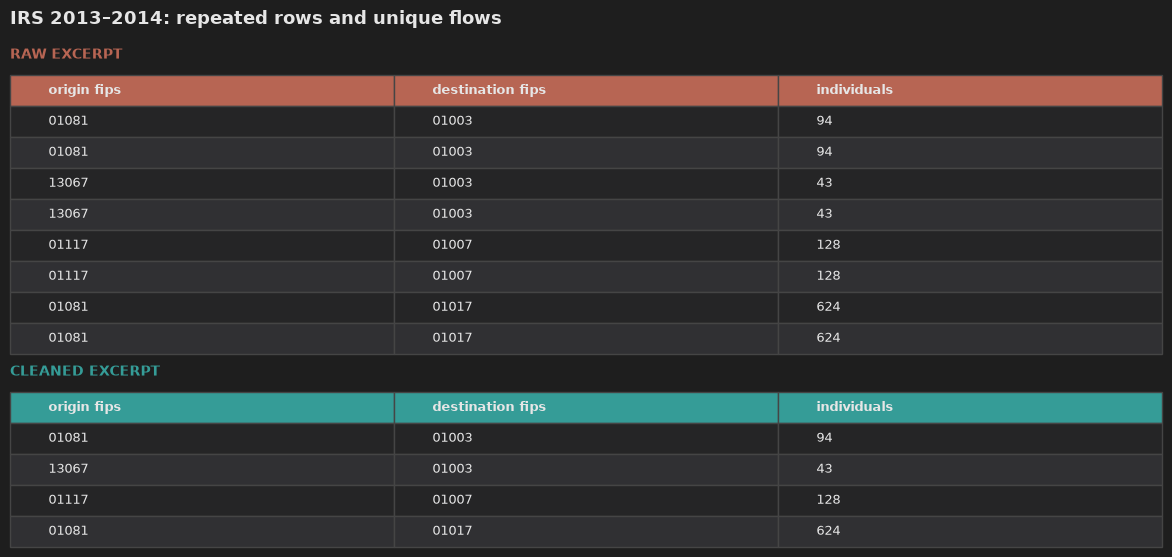

WindowsPath('C:/Users/kenny/Data Science Projects/us-migration/reports/figures/cleaning/02_irs_raw_vs_clean.png')

In [156]:
comparison_image(example.loc[ids,['origin_fips','destination_fips','individuals']],
 canonical_irs_pairs(example.loc[ids])[['origin_fips','destination_fips','individuals']],
 'IRS 2013–2014: repeated rows and unique flows','02_irs_raw_vs_clean.png')


### 3.10. Process and save interstate state totals

County outputs are now saved. Normalize the state CSV supplements, combine them with historical state totals, and assert unique state-year-direction keys when saving the Alaska and Connecticut series.


In [157]:
frames=[]
for logical,record in sorted(catalog.items()):
    parts=logical.split('/')
    if parts[0]=='irs_states':
        year=int(parts[1]) if parts[1].isdigit() else None
        if year is not None and not START_YEAR<=year<=END_YEAR: continue
        path,_=raw_snapshot(logical)
        frame=normalize_state_irs(pd.read_csv(path,dtype=str,encoding='cp1252'),year,parts[-1])
        frame['source_snapshot']=record['sha256']
        frames.append(frame)
        provenance.append(record)
state_csv=pd.concat(frames,ignore_index=True)
display(state_csv.head(4))


,ref_state,ref_county,other_state,other_county,other_state_name,other_name,returns,...,origin_fips,destination_fips,view,year,period_start,methodology_series,source_snapshot
0,02,000,97,000,AK,AK Total Migration-US,13352.0,...,97000,02000,inflow,2019,2018,2012_2022,5106544e24a33cd40319f00fc7a96ac46eab8697032122...
1,09,000,97,000,CT,CT Total Migration-US,39618.0,...,97000,09000,inflow,2019,2018,2012_2022,5106544e24a33cd40319f00fc7a96ac46eab8697032122...
2,02,000,97,000,AK,AK Total Migration-US,16508.0,...,02000,97000,outflow,2019,2018,2012_2022,f0edaeadb82f0fb306bf979159191285c612b3cbbccbda...
3,09,000,97,000,CT,CT Total Migration-US,48394.0,...,09000,97000,outflow,2019,2018,2012_2022,f0edaeadb82f0fb306bf979159191285c612b3cbbccbda...


In [158]:
print('state_csv:',f'{len(state_csv):,} records')


state_csv: 20 records


In [159]:
legacy=irs.loc[irs.county_fips.isin(['02000','09000'])&irs.other_fips.eq('97003')&irs.year.le(2018)].copy()
legacy['row_type']='domestic_total'
state_totals=pd.concat([legacy,state_csv],ignore_index=True)
save_table('irs_state_totals',state_totals,['county_fips','year','view'])
display(state_totals[['county_fips','year','view','individuals']].tail(6))

,county_fips,year,view,individuals
54,02000,2022,outflow,31733.0
55,09000,2022,outflow,88096.0
56,02000,2023,inflow,25599.0
57,09000,2023,inflow,76966.0
58,02000,2023,outflow,29748.0
59,09000,2023,outflow,81733.0


## 4. ACS migration flows: maintain geography and disclosure distinctions

### 4.1. Load ACS flow records and inspect ambiguous origin codes

Begin with an original state-origin Census response. Inspect mover estimates, margins of error and named regions that share a published origin code; those shared codes explain why code alone is not always a unique identifier.


In [160]:
flow_path,_=raw_snapshot('acs_state_flows/2021/counties')
raw_flow=api_frame(flow_path)
display(raw_flow[['GEOID1','GEOID2','FULL2_NAME','MOVEDIN','MOVEDIN_M']].head(6))
flow_numbers=raw_flow[['MOVEDIN','MOVEDIN_M']].apply(numeric)
display(pd.DataFrame({'missing':flow_numbers.isna().sum(),'negative_special_codes':flow_numbers.lt(0).sum()}))
display(raw_flow.loc[raw_flow.GEOID2.eq('AM'),['GEOID1','GEOID2','FULL2_NAME']].head(6))


,GEOID1,GEOID2,FULL2_NAME,MOVEDIN,MOVEDIN_M
0,01001,01,Alabama,2036,553
1,01001,04,Arizona,84,101
2,01001,08,Colorado,1,9
3,01001,12,Florida,23,34
4,01001,13,Georgia,352,458
5,01001,18,Indiana,10,17


,missing,negative_special_codes
MOVEDIN,0,0
MOVEDIN_M,0,0


,GEOID1,GEOID2,FULL2_NAME
25,01001,AM,South America
67,01003,AM,Central America
70,01003,AM,Northern America
71,01003,AM,South America
86,01005,AM,Central America
112,01009,AM,Central America


### 4.2. Define flow parsing and origin identification

Define the stages that read historical or JSON layouts, convert movers and uncertainty estimates, and identify domestic versus named foreign origins. Keep county-origin and state-origin vintages separate; absent flows are not zero.


**Transformation: Read the 2009 fixed-width layout or the later Census JSON response.**


In [161]:
def acs_flow_raw(path, year):
    if year==2009:
        # 2009 ctyxcty_us: 3-digit state/3-digit county pairs in first 12 chars;
        # final two whitespace-separated fields are movers and their 90% MOE.
        records=[]
        with path.open(encoding='latin-1') as source:
            for line in source:
                if not line.strip(): continue
                tail=line.split()[-2:]
                origin_state=line[6:9]
                origin=(origin_state[-2:] if origin_state.isdigit() and int(origin_state)<100 else origin_state)+line[9:12]
                records.append((line[:3].strip().zfill(3)[-2:]+line[3:6],origin,*tail))
        raw=pd.DataFrame(records,columns=['GEOID1','GEOID2','MOVEDIN','MOVEDIN_M'])
    else:
        raw=api_frame(path)
    return raw


**Transformation: Preserve published codes and convert movers and uncertainty estimates.**


In [162]:
def acs_flow_measures(raw, year):
    frame=pd.DataFrame({'destination_fips':raw.GEOID1.astype('string'),
        'origin_code':raw.GEOID2.astype('string').str.strip().replace('',pd.NA),'year':year,'period_start':year-4,'period_end':year,
        'movers':acs_numeric(raw.MOVEDIN),'movers_moe':acs_numeric(raw.MOVEDIN_M)})
    return frame


**Transformation: Identify domestic geography and distinguish named regions sharing a code.**


In [163]:
def acs_flow_origins(raw, frame, state_origin):
    width=2 if state_origin else 5
    frame['origin_geography']=np.where(frame.origin_code.str.fullmatch(r'\d{'+str(width)+'}').fillna(False),'state' if state_origin else 'county','world_region_or_other')
    frame['domestic_pair']=frame.destination_fips.str.fullmatch(r'\d{5}').fillna(False) & frame.origin_code.str.fullmatch(r'\d{'+str(width)+'}').fillna(False) & frame.origin_code.str[:2].isin(US_STATES) & frame.destination_fips.str[:2].isin(US_STATES)
    if not state_origin:
        frame['domestic_pair'] = frame.domestic_pair & frame.origin_code.str[2:].ne('000').fillna(False)
    for source,target in [('FULL1_NAME','destination_name'),('FULL2_NAME','origin_name')]:
        if source in raw: frame[target]=raw[source]
    frame['origin_id']=frame.origin_code
    if 'origin_name' in frame:
        other=frame.origin_geography.eq('world_region_or_other')
        frame.loc[other,'origin_id']='region:'+frame.loc[other,'origin_name'].astype('string').str.strip()
    return frame


The wrapper below combines the functions just defined in execution order. It defines the reusable recipe; the following example calls run it on data.


In [164]:
def clean_acs_flows(path,year,state_origin=False):
    raw=acs_flow_raw(path,year)
    frame=acs_flow_measures(raw,year)
    return acs_flow_origins(raw,frame,state_origin)


### 4.3. Apply the flow transformations to the example

Convert the loaded measurements first, then construct origin identities. Inspect the named-region results and verify equality with the combined function that will process the full collection.


In [165]:
flow_example=acs_flow_measures(raw_flow,2021)
display(flow_example[['destination_fips','origin_code','movers','movers_moe']].head())


,destination_fips,origin_code,movers,movers_moe
0,01001,01,2036.0,553.0
1,01001,04,84.0,101.0
2,01001,08,1.0,9.0
3,01001,12,23.0,34.0
4,01001,13,352.0,458.0


In [166]:
flow_example=acs_flow_origins(raw_flow,flow_example,True)
display(flow_example.loc[flow_example.origin_code.eq('AM'),['origin_code','origin_id','movers']].head(6))
pd.testing.assert_frame_equal(flow_example,clean_acs_flows(flow_path,2021,True))


,origin_code,origin_id,movers
25,AM,region:South America,34.0
67,AM,region:Central America,134.0
70,AM,region:Northern America,154.0
71,AM,region:South America,18.0
86,AM,region:Central America,32.0
112,AM,region:Central America,55.0


### 4.4. Compare and validate the transformed flow example

Compare the same records before and after origin identification. Assert unique destination-origin-year keys and nonnegative available mover counts before processing all vintages.


In [167]:
display(pd.DataFrame({'raw_code':raw_flow.GEOID2,'raw_name':raw_flow.FULL2_NAME,
 'clean_id':flow_example.origin_id,'raw_movers':raw_flow.MOVEDIN,'clean_movers':flow_example.movers}).loc[raw_flow.GEOID2.eq('AM')].head(6))
assert not flow_example.duplicated(['destination_fips','origin_id','year']).any()
assert flow_example.movers.dropna().ge(0).all()


,raw_code,raw_name,clean_id,raw_movers,clean_movers
25,AM,South America,region:South America,34,34.0
67,AM,Central America,region:Central America,134,134.0
70,AM,Northern America,region:Northern America,154,154.0
71,AM,South America,region:South America,18,18.0
86,AM,Central America,region:Central America,32,32.0
112,AM,Central America,region:Central America,55,55.0


### 4.5. Clean and validate all county-origin flow vintages

The example has passed its checks. Run the same cleaning function across every available county-origin snapshot, retain provenance, and inspect the combined distributions and keys.


In [168]:
frames=[]
for logical,record in sorted(catalog.items()):
    parts=logical.split('/')
    if parts[0]=='acs_flows' and (parts[-1].startswith('counties') or parts[-1]=='bulk'):
        year=int(parts[1]) if parts[1].isdigit() else None
        if year is not None and not START_YEAR<=year<=END_YEAR: continue
        path,_=raw_snapshot(logical)
        frame=clean_acs_flows(path,year,parts[0]=='acs_state_flows')
        frame['source_snapshot']=record['sha256']
        frames.append(frame)
        provenance.append(record)
acs_flows=pd.concat(frames,ignore_index=True)
display(acs_flows.head(4))


,destination_fips,origin_code,year,period_start,period_end,movers,movers_moe,origin_geography,domestic_pair,origin_id,source_snapshot,destination_name,origin_name
0,01001,01003,2009,2005,2009,35.0,56.0,county,True,01003,7a1bf982f308b97bb2bd9682a4fbdceac3485a5f5b9a01...,NaN,NaN
1,01001,01007,2009,2005,2009,38.0,60.0,county,True,01007,7a1bf982f308b97bb2bd9682a4fbdceac3485a5f5b9a01...,NaN,NaN
2,01001,01009,2009,2005,2009,100.0,131.0,county,True,01009,7a1bf982f308b97bb2bd9682a4fbdceac3485a5f5b9a01...,NaN,NaN
3,01001,01013,2009,2005,2009,11.0,15.0,county,True,01013,7a1bf982f308b97bb2bd9682a4fbdceac3485a5f5b9a01...,NaN,NaN


In [169]:
print('acs_flows:',f'{len(acs_flows):,} records')


acs_flows: 5,803,110 records


In [170]:
source_quality(acs_flows,['movers','movers_moe'],['destination_fips','origin_id','year'])


,variable,dtype,missing,missing_pct,minimum,median,maximum,iqr_outliers
0,movers,float64,1752,0.030191,0.0,8.0,48456.0,635128
1,movers_moe,float64,1752,0.030191,0.0,28.0,3049.0,724761


,count
rows,5803110
duplicate_keys,0
missing_measurements,3504
infinite_measurements,0
blank_or_missing_text_markers,0


### 4.6. Save county-origin flow records

The combined county-origin vintages have been profiled and checked for duplicate keys. Save them with their uncertainty estimates and missing-value evidence intact.


In [171]:
save_table('acs_county_flows',acs_flows,['destination_fips','origin_id','year'])

### 4.7. Clean and validate all state-origin flow vintages

Repeat the batch process for state-origin snapshots using the state-origin rule. Review this table independently because its geographic unit differs from the county-origin output.


In [172]:
frames=[]
for logical,record in sorted(catalog.items()):
    parts=logical.split('/')
    if parts[0]=='acs_state_flows' and parts[-1].startswith('counties'):
        year=int(parts[1]) if parts[1].isdigit() else None
        if year is not None and not START_YEAR<=year<=END_YEAR: continue
        path,_=raw_snapshot(logical)
        frame=clean_acs_flows(path,year,parts[0]=='acs_state_flows')
        frame['source_snapshot']=record['sha256']
        frames.append(frame)
        provenance.append(record)
acs_state_flows=pd.concat(frames,ignore_index=True)
display(acs_state_flows.head(4))


,destination_fips,origin_code,year,period_start,period_end,movers,movers_moe,origin_geography,domestic_pair,destination_name,origin_name,origin_id,source_snapshot
0,01001,01,2021,2017,2021,2036.0,553.0,state,True,Autauga County,Alabama,01,a60050978c4740dfb3f66d38e465fa9223fb470b8c8403...
1,01001,04,2021,2017,2021,84.0,101.0,state,True,Autauga County,Arizona,04,a60050978c4740dfb3f66d38e465fa9223fb470b8c8403...
2,01001,08,2021,2017,2021,1.0,9.0,state,True,Autauga County,Colorado,08,a60050978c4740dfb3f66d38e465fa9223fb470b8c8403...
3,01001,12,2021,2017,2021,23.0,34.0,state,True,Autauga County,Florida,12,a60050978c4740dfb3f66d38e465fa9223fb470b8c8403...


In [173]:
print('acs_state_flows:',f'{len(acs_state_flows):,} records')


acs_state_flows: 131,135 records


In [174]:
source_quality(acs_state_flows,['movers','movers_moe'],['destination_fips','origin_id','year'])


,variable,dtype,missing,missing_pct,minimum,median,maximum,iqr_outliers
0,movers,float64,0,0.0,1.0,35.0,107424.0,17793
1,movers_moe,float64,0,0.0,1.0,43.0,5624.0,12632


,count
rows,131135
duplicate_keys,0
missing_measurements,0
infinite_measurements,0
blank_or_missing_text_markers,0


### 4.8. Save state-origin flow records

Save the separately validated state-origin vintages. Keeping this output distinct prevents state origins from being interpreted as county origins.


In [175]:
save_table('acs_state_county_flows',acs_state_flows,['destination_fips','origin_id','year'])

### 4.9. Save a raw-versus-cleaned flow comparison

Both flow tables are saved. Return to the example response to save an image illustrating how named origins become distinct identifiers, and summarize remaining missing estimates by origin type.


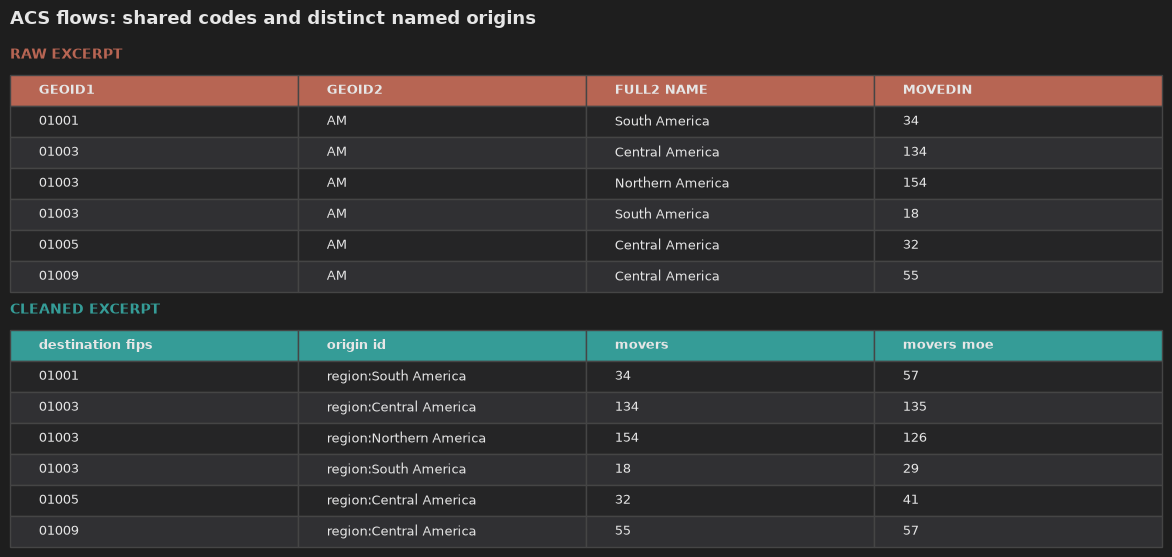

,records,missing
origin_geography,,
state,56385,0
world_region_or_other,9734,0


In [176]:
flow_path,_=raw_snapshot('acs_state_flows/2021/counties')
raw_flow=api_frame(flow_path);clean_flow=clean_acs_flows(flow_path,2021,True)
ids=raw_flow.index[raw_flow.GEOID2.eq('AM')][:6]
comparison_image(raw_flow.loc[ids,['GEOID1','GEOID2','FULL2_NAME','MOVEDIN']],
 clean_flow.loc[ids,['destination_fips','origin_id','movers','movers_moe']],
 'ACS flows: shared codes and distinct named origins','03_acs_flows_raw_vs_clean.png')
display(clean_flow.groupby('origin_geography').agg(records=('movers','size'),missing=('movers',lambda s:s.isna().sum())))

## 5. FEMA: parse dates, expose estimates, map areas and deduplicate incidents

### 5.1. Load FEMA area records and diagnose raw dates

Start with original date strings and count missing or unparseable dates. A disaster can appear in many area rows, so subsequent date-completion decisions use distinct disasters rather than treating repeated areas as independent incidents.


In [177]:
fema_path,_=raw_snapshot('fema/declarations')
raw_fema=pd.read_csv(fema_path,dtype=str)
display(raw_fema[['disasterNumber','designatedArea','incidentBeginDate','incidentEndDate']].head(6))
fema_date_check=raw_fema[['incidentBeginDate','incidentEndDate']].apply(lambda s:pd.to_datetime(s,errors='coerce',utc=True))
display(pd.DataFrame({'raw_missing':raw_fema[fema_date_check.columns].isna().sum(),
 'unparseable_nonmissing':(fema_date_check.isna()&raw_fema[fema_date_check.columns].notna()).sum()}))


,disasterNumber,designatedArea,incidentBeginDate,incidentEndDate
0,5672,Southeast Fairbanks (Census Area),2026-08-17T00:00:00.000Z,NaN
1,5670,Jackson (County),2026-08-13T00:00:00.000Z,NaN
2,5670,Josephine (County),2026-08-13T00:00:00.000Z,NaN
3,5669,Oklahoma (County),2026-08-13T00:00:00.000Z,2026-08-16T00:00:00.000Z
4,5669,Canadian (County),2026-08-13T00:00:00.000Z,2026-08-16T00:00:00.000Z
5,5666,Klamath (County),2026-08-05T00:00:00.000Z,NaN


,raw_missing,unparseable_nonmissing
incidentBeginDate,0,0
incidentEndDate,666,0


### 5.2. Define FEMA date parsing and period selection

Construct FIPS, parse timestamps, calculate durations and select the study period.

**Transformation: Validate the schema, construct FIPS, and parse timestamps without guessing dates.**


In [178]:
def fema_dates(frame):
    frame=frame.copy()
    required={'fipsStateCode','fipsCountyCode','incidentBeginDate','declarationDate','disasterNumber'}
    if not required.issubset(frame):
        raise ValueError('FEMA schema missing required fields')
    frame['county_fips']=code(frame.fipsStateCode,2)+code(frame.fipsCountyCode,3)
    for col in ['incidentBeginDate','incidentEndDate','declarationDate']:
        frame[col]=pd.to_datetime(frame[col],errors='coerce',utc=True)
    return frame


**Transformation: Calculate durations and select incident years, retaining missing starts for review.**


In [179]:
def fema_scope(frame, start, end):
    frame['year']=frame.incidentBeginDate.dt.year.astype('Int64')
    frame['county_coded_us']=frame.county_fips.str[:2].isin(US_STATES) & frame.county_fips.str[2:].ne('000') & frame.county_fips.str.fullmatch(r'\d{5}').fillna(False)
    frame['duration_days']=(frame.incidentEndDate-frame.incidentBeginDate).dt.total_seconds()/86400+1
    frame['invalid_duration']=frame.duration_days.lt(0)
    # Preserve missing incident dates if the declaration falls in the requested period.
    selected=frame.year.between(start,end) | (frame.year.isna() & frame.declarationDate.dt.year.between(start,end))
    return frame.loc[selected].copy()


The wrapper below combines the functions just defined in execution order. It defines the reusable recipe; the following example calls run it on data.


In [180]:
def clean_fema(path,start,end):
    frame=pd.read_csv(path,dtype=str)
    return fema_scope(fema_dates(frame),start,end)


### 5.3. Apply date parsing and inspect duration problems

Run the parsing and period-selection stages on the raw table. Inspect durations and invalid-date flags, verify agreement with the combined reader, and save the standardized source records before end-date completion.


In [181]:
fema_example=fema_dates(raw_fema)
display(fema_example[['county_fips','incidentBeginDate','incidentEndDate']].head())


,county_fips,incidentBeginDate,incidentEndDate
0,02240,2026-08-17 00:00:00+00:00,NaT
1,41029,2026-08-13 00:00:00+00:00,NaT
2,41033,2026-08-13 00:00:00+00:00,NaT
3,40109,2026-08-13 00:00:00+00:00,2026-08-16 00:00:00+00:00
4,40017,2026-08-13 00:00:00+00:00,2026-08-16 00:00:00+00:00


In [182]:
fema_example=fema_scope(fema_example,START_YEAR,END_YEAR)
display(fema_example[['disasterNumber','year','duration_days','invalid_duration']].head())
print('Negative durations:',int(fema_example.invalid_duration.sum()))
pd.testing.assert_frame_equal(fema_example,clean_fema(fema_path,START_YEAR,END_YEAR))


,disasterNumber,year,duration_days,invalid_duration
0,5672,2026,NaN,False
1,5670,2026,NaN,False
2,5670,2026,NaN,False
3,5669,2026,4.0,False
4,5669,2026,4.0,False


Negative durations: 0


In [183]:
fema_path,record=raw_snapshot('fema/declarations')
provenance.append(record)
fema=clean_fema(fema_path,START_YEAR,END_YEAR)
save_table('fema_declarations',fema,['id'])
display(fema[['disasterNumber','designatedArea','incidentBeginDate','incidentEndDate']].head())
print('Missing end dates in area rows:',fema.incidentEndDate.isna().sum())

,disasterNumber,designatedArea,incidentBeginDate,incidentEndDate
0,5672,Southeast Fairbanks (Census Area),2026-08-17 00:00:00+00:00,NaT
1,5670,Jackson (County),2026-08-13 00:00:00+00:00,NaT
2,5670,Josephine (County),2026-08-13 00:00:00+00:00,NaT
3,5669,Oklahoma (County),2026-08-13 00:00:00+00:00,2026-08-16 00:00:00+00:00
4,5669,Canadian (County),2026-08-13 00:00:00+00:00,2026-08-16 00:00:00+00:00


Missing end dates in area rows: 359


### 5.4. Complete missing end dates using training incidents

With missing dates identified, measure their share per distinct disaster. If at most 5% are missing, exclude those declarations; otherwise estimate durations from eligible incidents whose start and end dates are both on or before December 31, 2018. Reuse those fitted medians across all splits, flag estimates, and save the date-completion audit.


In [184]:
def finish_fema_dates(events, train_end=TRAIN_END):
    """One duration per disaster number; fit duration estimates on training incidents."""
    frame=events.copy()
    groups=frame.groupby('disasterNumber')
    incidents=groups.agg(start=('incidentBeginDate','min'),end=('incidentEndDate','max'),
                         incident_type=('incidentType','first'))
    missing=incidents.end.isna()
    fraction=float(missing.mean())
    # Reconcile repeated area rows using an observed end from the same declaration.
    frame['incident_end_imputed']=False
    frame['incidentEndDate']=frame.disasterNumber.map(incidents.end)
    duration=(incidents.end-incidents.start).dt.total_seconds()/86400
    train=incidents.start.dt.year.le(train_end)&incidents.end.dt.year.le(train_end)&duration.ge(0)
    fitted=duration.loc[train].groupby(incidents.loc[train,'incident_type']).median()
    global_duration=duration.loc[train].median()
    if not np.isfinite(global_duration): raise ValueError('No training incident durations')
    if fraction <= SMALL_MISSING_FRACTION:
        frame=frame.loc[~frame.disasterNumber.isin(incidents.index[missing])].copy()
        action='drop missing-end declarations'
    else:
        estimates=incidents.incident_type.map(fitted).fillna(global_duration).round().clip(lower=0)
        ids=incidents.index[missing & incidents.start.notna()]
        replacement=incidents.loc[ids,'start']+pd.to_timedelta(estimates.loc[ids],unit='D')
        fill=frame.disasterNumber.isin(ids)
        frame.loc[fill,'incidentEndDate']=frame.loc[fill,'disasterNumber'].map(replacement)
        frame.loc[fill,'incident_end_imputed']=True
        action='training incident-type median duration; training global median fallback'
    frame['duration_days']=(frame.incidentEndDate-frame.incidentBeginDate).dt.total_seconds()/86400+1
    frame['invalid_duration']=frame.duration_days.lt(1)
    invalid=frame.incidentBeginDate.isna()|frame.incidentEndDate.isna()|frame.invalid_duration
    rejected=frame.loc[invalid].copy()
    frame=frame.loc[~invalid].copy()
    report={'declarations':len(incidents),'missing_end_declarations':int(missing.sum()),
            'missing_end_pct':100*fraction,'missing_end_area_rows':int(events.incidentEndDate.isna().sum()),
            'small_missing_threshold_pct':100*SMALL_MISSING_FRACTION,'action':action,
            'training_end_year':train_end,'training_declarations':int(train.sum()),
            'global_duration_days':float(global_duration),'duration_days_by_type':fitted.to_dict(),
            'rejected_area_rows':len(rejected)}
    return frame,report,rejected

In [185]:
dated,date_report,date_rejected=finish_fema_dates(fema)
assert dated[['incidentBeginDate','incidentEndDate','duration_days']].notna().all().all()
assert dated.duration_days.ge(1).all()
save_table('fema_cleaned_incidents',dated,['id'])
(DATA/'fema_date_cleaning.json').write_text(json.dumps(date_report,indent=2))
date_rejected.to_csv(DATA/'fema_date_exclusions.csv',index=False)
display(pd.DataFrame([date_report]).drop(columns='duration_days_by_type').T)

,0
declarations,2362
missing_end_declarations,191
missing_end_pct,8.086367
missing_end_area_rows,359
small_missing_threshold_pct,5.0
action,training incident-type median duration; traini...
training_end_year,2018
training_declarations,1136
global_duration_days,7.0
rejected_area_rows,0


### 5.5. Validate completed dates and compare matching records

Check that retained incidents have valid start/end dates and positive inclusive durations. Compare the same area IDs before and after completion so the estimated dates and their flags are visible.


In [186]:
assert dated[['incidentBeginDate','incidentEndDate','duration_days']].notna().all().all()
assert dated.duration_days.ge(1).all()
fema_date_comparison=fema[['id','incidentEndDate']].merge(
 dated[['id','incidentEndDate','incident_end_imputed']],on='id',suffixes=('_before','_after'),validate='one_to_one')
display(fema_date_comparison.loc[fema_date_comparison.incident_end_imputed].head(6))


,id,incidentEndDate_before,incidentEndDate_after,incident_end_imputed
0,5f3cd139-146c-4b95-be63-f0e4f19e02af,NaT,2026-08-25 00:00:00+00:00,True
1,cf7d9b91-231a-4e41-b5ac-dc2306fe3f50,NaT,2026-08-21 00:00:00+00:00,True
2,fe2653a9-426f-463e-8c08-fcbf9e76bb31,NaT,2026-08-21 00:00:00+00:00,True
5,c077b64f-30db-4fbf-a254-0783c25811e8,NaT,2026-08-13 00:00:00+00:00,True
6,7ec47bda-2cfc-4aa4-9691-c5f664ebe345,NaT,2026-08-17 00:00:00+00:00,True
7,45f22dc3-a4f6-487a-a354-be90053f1513,NaT,2026-08-17 00:00:00+00:00,True


### 5.6. Define geographic-name normalization

Dates are now ready for geographic mapping. Standardize punctuation and generic suffixes so reference names can be compared consistently; normalization must not choose between ambiguous entities.


In [187]:
def area_key(name):
    text=unicodedata.normalize('NFKD',str(name)).encode('ascii','ignore').decode().lower()
    text=re.sub(r'\(also[^)]*\)','',text)
    text=re.sub(r'\b(indian|reservation|off|trust|lands?|tribe|of|the|community|anvsa|anv|tdsa|otsa|county|borough|census area)\b',' ',text)
    return ' '.join(sorted(re.findall(r'[a-z0-9]+',text)))

### 5.7. Define statewide and tribal mapping rules

Using normalized names and reference geography, define explicit statewide expansion and unambiguous Census 2020 tribal land-overlap mapping. Retain unmatched areas for review. A tribal overlap indicates partial-county exposure; Alaska and Connecticut use state units.


In [188]:
def map_fema_areas(events, geography, relationships):
    """Map only explicit statewide areas, known FIPS, or unambiguous reference names."""
    geo=geography[['county_fips','county_name','year']].drop_duplicates().copy()
    geo['state']=geo.county_fips.str[:2]
    geo['key']=geo.county_name.str.split(',').str[0].map(area_key)
    rel=relationships.dropna(subset=['GEOID_AIANNH_20']).copy()
    rel['key']=rel.NAMELSAD_AIANNH_20.map(area_key)
    rel=rel.loc[pd.to_numeric(rel.AREALAND_PART,errors='coerce').gt(0)]
    # Different official entities with the same stripped name are not guessed.
    mappings={}
    for key,g in rel.groupby('key'):
        if g.GEOID_AIANNH_20.str[:4].nunique()==1:
            mappings[key]=sorted(g.GEOID_COUNTY_20.dropna().unique())
    years=sorted(geo.year.unique())
    lookup={year:g for year,g in geo.groupby('year')}
    valid_codes={year:set(g.county_fips) for year,g in lookup.items()}
    state_codes={(year,state):g.county_fips.tolist() for year,ref in lookup.items() for state,g in ref.groupby('state')}
    name_codes={(year,state,key):g.county_fips.unique() for year,ref in lookup.items() for (state,key),g in ref.groupby(['state','key'])}
    rows=[]; unresolved=[]
    for _,record in events.iterrows():
        year=int(record.year)
        reference_year=max((y for y in years if y<=year),default=years[0])
        ref=lookup[reference_year]
        state=str(record.fipsStateCode).zfill(2)
        name=str(record.designatedArea)
        code=str(record.county_fips)
        method=''; targets=[]
        if state in STATE_UNITS:
            targets=[state+'000']; method='state_analysis_unit'
        elif name.strip().lower()=='statewide':
            targets=state_codes.get((reference_year,state),[]); method='statewide_expansion'
        elif code in valid_codes[reference_year]:
            targets=[code];method='published_county_fips'
        else:
            key=area_key(name)
            candidate=name_codes.get((reference_year,state,key),[])
            if len(candidate)==1:
                targets=list(candidate);method='exact_county_name_reference'
            elif key in mappings:
                candidate=mappings[key]
                # Retain all intersecting counties for a cross-state tribal designation.
                if any(c.startswith(state) for c in candidate):
                    valid=valid_codes[reference_year]
                    targets=[c for c in candidate if c in valid]
                    method='tribal_2020_land_overlap'
        if not targets:
            unresolved.append(record.to_dict());continue
        for target in sorted(set(targets)):
            item=record.to_dict();item['source_county_fips']=code
            item['county_fips']=target;item['mapping_method']=method
            item['geography_reference_year']=2020 if method.startswith('tribal') else reference_year
            rows.append(item)
    mapped=pd.DataFrame(rows)
    return mapped,pd.DataFrame(unresolved,columns=events.columns)

### 5.8. Apply geographic mapping and save annual declaration counts

Run the mapping rules, inspect how many rows each method resolves, and deduplicate disaster numbers within geography-years. Validate and save the mapping and annual counts, preserve unresolved areas, and display before/after geographic examples. These counts do not depend on estimated incident durations.


In [189]:
rel_path,record=raw_snapshot('geography/2020/tribal_counties');provenance.append(record)
rel_path,record=raw_snapshot('geography/2020/tribal_counties');provenance.append(record)
relationships=pd.read_csv(rel_path,sep='|',dtype=str,encoding='utf-8-sig')
mapped,unmapped=map_fema_areas(dated,acs.loc[acs.in_scope_us],relationships)
save_table('fema_area_county_mapping',mapped,['id','county_fips'])
unmapped.to_csv(DATA/'fema_unresolved_areas.csv',index=False)
annual_fema=mapped.groupby(KEYS,as_index=False).agg(declarations=('disasterNumber','nunique'),incident_types=('incidentType','nunique'))
assert annual_fema[['declarations','incident_types']].ge(0).all().all()
assert not annual_fema.duplicated(KEYS).any()
save_table('fema_county_year',annual_fema,KEYS)
display(mapped.groupby('mapping_method').agg(source_rows=('id','nunique'),mapped_rows=('id','size')))
print('Unresolved area rows retained for review:',len(unmapped))
examples=pd.concat([mapped.loc[mapped.mapping_method.eq('statewide_expansion')].head(3),mapped.loc[mapped.mapping_method.eq('tribal_2020_land_overlap')].head(3)])


,source_rows,mapped_rows
mapping_method,,
exact_county_name_reference,84,84
published_county_fips,31573,31573
state_analysis_unit,387,387
statewide_expansion,8,862
tribal_2020_land_overlap,629,1683


Unresolved area rows retained for review: 1609


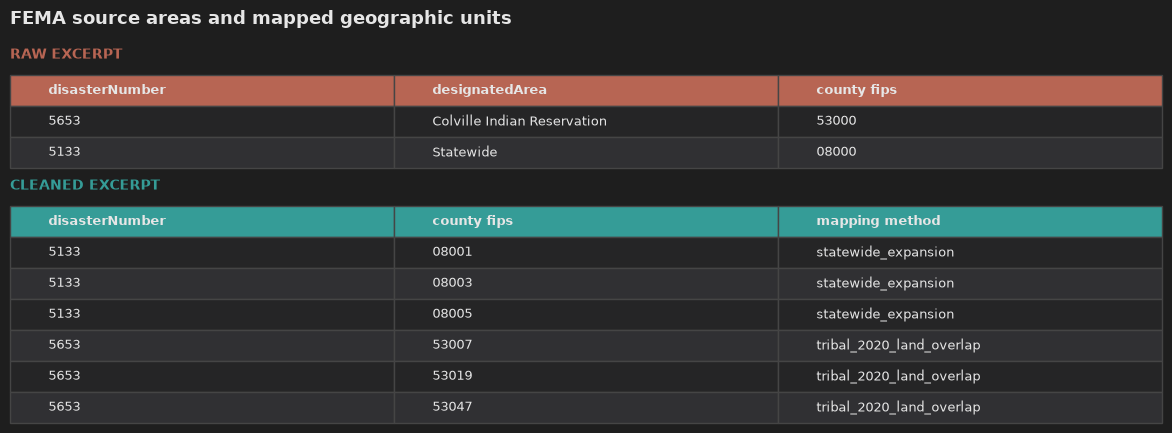

WindowsPath('C:/Users/kenny/Data Science Projects/us-migration/reports/figures/cleaning/04_fema_raw_vs_clean.png')

In [190]:
comparison_image(fema.loc[fema.id.isin(examples.id),['disasterNumber','designatedArea','county_fips']].head(6),
 examples[['disasterNumber','county_fips','mapping_method']],
 'FEMA source areas and mapped geographic units','04_fema_raw_vs_clean.png')


In [191]:
source_quality(annual_fema,['declarations','incident_types'],KEYS)
assert annual_fema.declarations.ge(0).all()
assert not mapped.duplicated(['id','county_fips']).any()


,variable,dtype,missing,missing_pct,minimum,median,maximum,iqr_outliers
0,declarations,int64,0,0.0,1.0,1.0,12.0,890
1,incident_types,int64,0,0.0,1.0,1.0,4.0,2968


,count
rows,19440
duplicate_keys,0
missing_measurements,0
infinite_measurements,0
blank_or_missing_text_markers,0


## 6. NOAA: parse fixed-width measurements, mask sentinels and require full years

### 6.1. Load NOAA fixed-width records and inspect sentinel codes

Start with the original DC record for the latest snapshot year. Its monthly fields make published missing markers visible before cleaning, including months not yet available in a partial year.


In [192]:
noaa_path,_=raw_snapshot('noaa/tmpccy')
noaa_snapshot_year=int(catalog['noaa/tmpccy']['retrieved_at'][:4])
with noaa_path.open() as source:
    noaa_lines=[line for line in source if line[:5]=='18511' and line[7:11].isdigit() and int(line[7:11])==noaa_snapshot_year]
noaa_preview=pd.read_fwf(io.StringIO(''.join(noaa_lines)),widths=[2,3,2,4]+[7]*12,
 names=['climate_state','county','element','year']+[str(i) for i in range(1,13)],dtype=str)
display(noaa_preview)
noaa_numbers=noaa_preview[[str(i) for i in range(1,13)]].apply(numeric)
print('Published temperature sentinels:',int(noaa_numbers.isin([-99.99,-99.90]).sum().sum()))


,climate_state,county,element,year,1,2,3,...,6,7,8,9,10,11,12
0,18,511,02,2026,31.30,34.70,50.70,...,74.70,79.70,77.90,-99.90,-99.90,-99.90,-99.90


Published temperature sentinels: 4


### 6.2. Define climate parsing, geographic mapping and missing-value rules

Define four stages: read the requested years, translate climate IDs into Census FIPS, reshape monthly columns into rows, and mask element-specific missing markers. The DC crosswalk exception is explicit; negative sentinels must not become apparent extreme cold.


**Transformation: Read fixed-width monthly fields; restrict the requested years before parsing.**


In [193]:
def noaa_raw(path, start, end):
    # Filter the text before pandas parsing: full originals retain 1895 onward.
    with path.open() as source:
        lines=[line for line in source if line[7:11].isdigit() and start<=int(line[7:11])<=end]
    columns=['climate_state','county','element','year']+[str(i) for i in range(1,13)]
    raw=pd.read_fwf(io.StringIO(''.join(lines)),widths=[2,3,2,4]+[7]*12,names=columns,dtype=str)
    return raw


**Transformation: Translate climate-state IDs to Census FIPS, including the DC exception.**


In [194]:
def noaa_geography(raw):
    raw=raw.copy()
    raw['climate_state']=code(raw.climate_state,2)
    raw['county_fips']=raw.climate_state.map(NOAA_STATE_FIPS)+code(raw.county,3)
    # NOAA's county crosswalk maps NCDC 18511 to DC's Census code 11001.
    raw.loc[raw.climate_state.eq('18') & code(raw.county,3).eq('511'),'county_fips']='11001'
    if raw.county_fips.isna().any(): raise ValueError('Unmapped NOAA state ID')
    raw['year']=pd.to_numeric(raw.year)
    return raw


**Transformation: Reshape the twelve published monthly columns into one observation per month.**


In [195]:
def noaa_months(raw):
    result=raw.melt(id_vars=['county_fips','year'],value_vars=[str(i) for i in range(1,13)],var_name='month',value_name='value')
    result['month']=pd.to_numeric(result.month)
    result['value']=numeric(result.value)
    return result


**Transformation: Mask documented element-specific sentinels and retain a missing-sentinel flag.**


In [196]:
def noaa_values(result, element):
    sentinels=[-9.99] if element=='pcpncy' else [-99.99,-99.90]
    result['missing_sentinel']=result.value.isin(sentinels)
    result['value']=result.value.mask(result.missing_sentinel)
    result['variable']={'pcpncy':'precipitation_inches','tmpccy':'temperature_f','tmaxcy':'tmax_f','tmincy':'tmin_f'}[element]
    return result


The wrapper below combines the functions just defined in execution order. It defines the reusable recipe; the following example calls run it on data.


In [197]:
def clean_noaa(path,element,start,end):
    raw=noaa_raw(path,start,end)
    raw=noaa_geography(raw)
    result=noaa_months(raw)
    return noaa_values(result,element)


### 6.3. Apply the climate transformations to the example

Map the example geography, reshape its twelve months, then mask sentinels. Inspect the outputs and verify that flagged sentinel measurements are missing and the DC identifier is correct.


In [198]:
noaa_example=noaa_geography(noaa_preview)
display(noaa_example[['climate_state','county','county_fips','year']])
noaa_example=noaa_months(noaa_example)
display(noaa_example.tail(5))


,climate_state,county,county_fips,year
0,18,511,11001,2026


,county_fips,year,month,value
7,11001,2026,8,77.9
8,11001,2026,9,-99.9
9,11001,2026,10,-99.9
10,11001,2026,11,-99.9
11,11001,2026,12,-99.9


In [199]:
noaa_example=noaa_values(noaa_example,'tmpccy')
display(noaa_example.tail(5))
assert noaa_example.loc[noaa_example.missing_sentinel,'value'].isna().all()
assert noaa_example.county_fips.eq('11001').all()


,county_fips,year,month,value,missing_sentinel,variable
7,11001,2026,8,77.9,False,temperature_f
8,11001,2026,9,NaN,True,temperature_f
9,11001,2026,10,NaN,True,temperature_f
10,11001,2026,11,NaN,True,temperature_f
11,11001,2026,12,NaN,True,temperature_f


### 6.4. Compare all twelve months before and after cleaning

Place the original and cleaned values beside each other for the same months. It is expected that future months in the current year have missing values. The annual calculation defined below will require a full twelve valid months.


In [200]:
display(pd.DataFrame({'month':range(1,13),'raw_value':noaa_numbers.iloc[0].to_numpy(),
 'clean_value':noaa_example.value.to_numpy(),'sentinel_flag':noaa_example.missing_sentinel.to_numpy()}))


,month,raw_value,clean_value,sentinel_flag
0,1,31.3,31.3,False
1,2,34.7,34.7,False
2,3,50.7,50.7,False
3,4,60.4,60.4,False
4,5,63.8,63.8,False
5,6,74.7,74.7,False
6,7,79.7,79.7,False
7,8,77.9,77.9,False
8,9,-99.9,NaN,True
9,10,-99.9,NaN,True


### 6.5. Clean and combine all county climate files

The worked example shows how missing codes are handled. Apply the shared functions across the downloaded climate elements and study years, retain provenance and combine the monthly observations before annual aggregation.


In [201]:
frames=[]
for logical,record in sorted(catalog.items()):
    parts=logical.split('/')
    if parts[0]=='noaa' and parts[-1] in ['tmpccy','pcpncy','tmaxcy','tmincy']:
        year=int(parts[1]) if parts[1].isdigit() else None
        if year is not None and not START_YEAR<=year<=END_YEAR: continue
        path,_=raw_snapshot(logical)
        frame=clean_noaa(path,parts[-1],START_YEAR,END_YEAR)
        frame['source_snapshot']=record['sha256']
        frames.append(frame)
        provenance.append(record)
monthly=pd.concat(frames,ignore_index=True)
display(monthly.head(4))


,county_fips,year,month,value,missing_sentinel,variable,source_snapshot
0,01001,2009,1,3.26,False,precipitation_inches,894b621b949e6f1f23e12e5170ed3f7c755980788925b3...
1,01001,2010,1,6.51,False,precipitation_inches,894b621b949e6f1f23e12e5170ed3f7c755980788925b3...
2,01001,2011,1,2.66,False,precipitation_inches,894b621b949e6f1f23e12e5170ed3f7c755980788925b3...
3,01001,2012,1,5.26,False,precipitation_inches,894b621b949e6f1f23e12e5170ed3f7c755980788925b3...


In [202]:
print('monthly:',f'{len(monthly):,} records')


monthly: 2,714,688 records


### 6.6. Define annual statistics and validate monthly coverage

The combined monthly table is ready for aggregation. Define annual means for temperature and totals for precipitation, requiring twelve valid months. Validate monthly keys and report completeness by year; partial-current-year records are excluded from annual observations.


In [203]:
def annual_climate(monthly, as_of_year):
    grouped=monthly.groupby(['county_fips','year','variable']).value
    annual=grouped.agg(['count','mean','sum']).reset_index()
    annual['value']=np.where(annual.variable.eq('precipitation_inches'),annual['sum'],annual['mean'])
    annual.loc[annual['count'].ne(12),'value']=np.nan
    values=annual.pivot(index=['county_fips','year'],columns='variable',values='value')
    counts=annual.pivot(index=['county_fips','year'],columns='variable',values='count').add_suffix('_months')
    full=values.join(counts).reset_index()
    bad=full[counts.columns].ne(12).any(axis=1)
    audit=full.assign(incomplete=bad).groupby('year').agg(observations=('incomplete','size'),incomplete=('incomplete','sum'))
    audit['incomplete_pct']=100*audit.incomplete/audit.observations
    # A partial current year is not an annual observation, regardless of its share.
    drop=bad & full.year.ge(as_of_year)
    return full.loc[~drop].copy(),audit.reset_index(),full.loc[drop].copy()

In [204]:
source_quality(monthly,['value'],['county_fips','year','month','variable'])
assert monthly.month.between(1,12).all()
assert monthly.county_fips.str.fullmatch(r'\d{5}').all()


,variable,dtype,missing,missing_pct,minimum,median,maximum,iqr_outliers
0,value,float64,50272,1.851852,-33.0,46.3,112.2,0


,count
rows,2714688
duplicate_keys,0
missing_measurements,50272
infinite_measurements,0
blank_or_missing_text_markers,0


### 6.7. Save climate observations and completeness audits

Apply the annual aggregation rule and save monthly evidence, annual county statistics and excluded-year records. Display the completeness report and save the raw-versus-cleaned DC example.


In [205]:
save_table('climate_monthly',monthly,['county_fips','year','month','variable'])
snapshot_year=int(catalog['noaa/tmpccy']['retrieved_at'][:4])
climate,climate_quality,incomplete_years=annual_climate(monthly,snapshot_year)
save_table('climate_county_year',climate,KEYS)
climate_quality.to_csv(DATA/'climate_monthly_completeness.csv',index=False)
incomplete_years.to_parquet(DATA/'climate_incomplete_years.parquet',index=False)
display(climate_quality)
print('Incomplete percentage:',100*climate_quality.incomplete.sum()/climate_quality.observations.sum())
path,_=raw_snapshot('noaa/tmpccy')
line=next(line for line in path.read_text().splitlines() if line[:5]=='18511' and int(line[7:11])==snapshot_year)
raw_dc=pd.DataFrame({'NCDC county':['18511']*12,'year':snapshot_year,'month':range(1,13),'temperature_raw':[float(line[11+7*i:18+7*i]) for i in range(12)]})
observed=monthly.loc[monthly.county_fips.eq('11001')&monthly.year.eq(snapshot_year)&monthly.variable.eq('temperature_f')&monthly.value.notna()]


,year,observations,incomplete,incomplete_pct
0,2009,3142,0,0.0
1,2010,3142,0,0.0
2,2011,3142,0,0.0
3,2012,3142,0,0.0
4,2013,3142,0,0.0
5,2014,3142,0,0.0
6,2015,3142,0,0.0
7,2016,3142,0,0.0
8,2017,3142,0,0.0
9,2018,3142,0,0.0


Incomplete percentage: 5.555555555555555


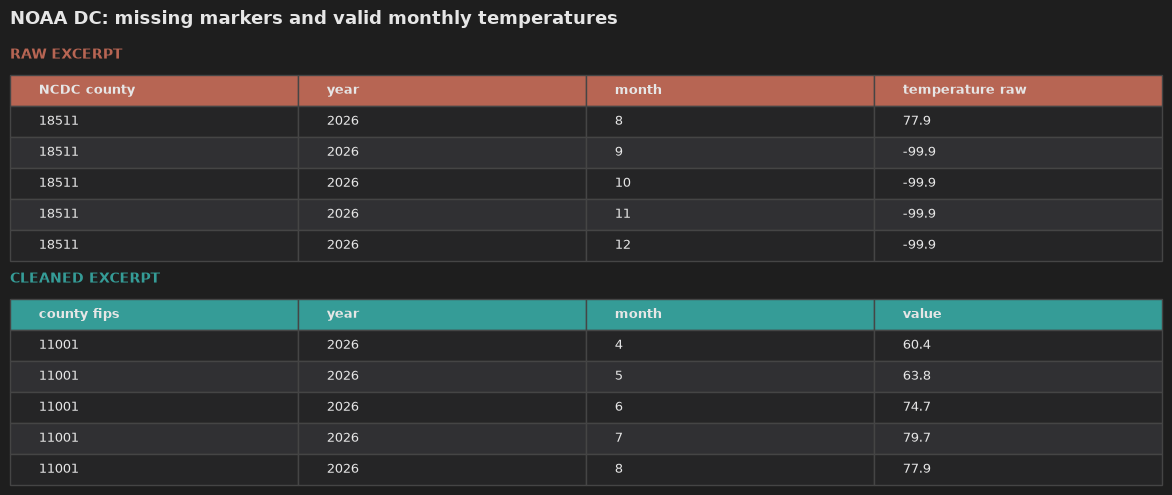

WindowsPath('C:/Users/kenny/Data Science Projects/us-migration/reports/figures/cleaning/05_noaa_raw_vs_clean.png')

In [206]:
comparison_image(raw_dc.tail(5),observed[['county_fips','year','month','value']].tail(5),
 'NOAA DC: missing markers and valid monthly temperatures','05_noaa_raw_vs_clean.png')


### 6.8. Process and save official state climate supplements

Finish the climate source by applying the same completeness requirement to official statewide series for Alaska and Connecticut. Use published state values rather than averaging counties whose boundaries or composition can change.


In [207]:
def clean_state_climate(path, element, start, end):
    rows=[]
    name={'tmpcst':'temperature_f','pcpnst':'precipitation_inches','tmaxst':'tmax_f','tminst':'tmin_f'}[element]
    for line in path.read_text().splitlines():
        state=NOAA_STATE_FIPS.get(line[:3].lstrip('0').zfill(2))
        if state not in STATE_UNITS or line[3:4]!='0': continue
        year=int(line[6:10])
        if not start<=year<=end:continue
        for month in range(1,13):
            value=float(line[10+(month-1)*7:17+(month-1)*7])
            if value in [-9.99,-99.90,-99.99]:value=np.nan
            rows.append((state+'000',year,month,name,value))
    return pd.DataFrame(rows,columns=['county_fips','year','month','variable','value'])

In [208]:
frames=[]
for logical,record in sorted(catalog.items()):
    parts=logical.split('/')
    if parts[0]=='noaa_states':
        year=int(parts[1]) if parts[1].isdigit() else None
        if year is not None and not START_YEAR<=year<=END_YEAR: continue
        path,_=raw_snapshot(logical)
        frame=clean_state_climate(path,parts[-1],START_YEAR,END_YEAR)
        frame['source_snapshot']=record['sha256']
        frames.append(frame)
        provenance.append(record)
state_monthly=pd.concat(frames,ignore_index=True)
display(state_monthly.head(4))


,county_fips,year,month,variable,value,source_snapshot
0,09000,2009,1,precipitation_inches,3.00,56b67e12075a65213d7a2cbaf39ef3ba0cee25dd84f562...
1,09000,2009,2,precipitation_inches,1.48,56b67e12075a65213d7a2cbaf39ef3ba0cee25dd84f562...
2,09000,2009,3,precipitation_inches,2.35,56b67e12075a65213d7a2cbaf39ef3ba0cee25dd84f562...
3,09000,2009,4,precipitation_inches,3.95,56b67e12075a65213d7a2cbaf39ef3ba0cee25dd84f562...


In [209]:
print('state_monthly:',f'{len(state_monthly):,} records')


state_monthly: 1,728 records


In [210]:
state_climate,_,_=annual_climate(state_monthly,snapshot_year)
save_table('climate_state_year',state_climate,KEYS)

## 7. Join validated geography and inspect every source table

Official state ACS medians replace county medians for Alaska and Connecticut due to change in county and borough boundaries over the analysis period. Their IRS outcomes measure interstate movement; other units measure intercounty movement. The compatibility codes `02000` and `09000` are labeled `geography_level=state`. Keep geography levels separate in comparisons. All joins enforce one observation per key.

### 7.1. Define the join and migration calculations

With all source tables available, define their geography-year joins and derive net migration and rates. Only absent FEMA counts in completed snapshot years become zero; missing IRS outcomes remain missing. Source windows differ, so rates are descriptive.


In [211]:
def build_panel(acs,irs,fema,climate,fema_complete_through):
    panel=acs.loc[acs.in_scope_us].copy()
    if not irs.empty:
        totals=irs.loc[irs.row_type.eq('domestic_total')]
        for view in ['inflow','outflow']:
            subset=totals.loc[totals.view.eq(view),['county_fips','year','individuals','returns']].rename(columns={'individuals':view+'_individuals','returns':view+'_returns'})
            panel=panel.merge(subset,on=['county_fips','year'],how='left',validate='one_to_one')
        panel['net_individuals']=panel.inflow_individuals-panel.outflow_individuals
        for col in ['inflow_individuals','outflow_individuals','net_individuals']:
            panel[col+'_per_1000']=1000*panel[col]/panel.population.where(panel.population>0)
    if not fema.empty:
        panel=panel.merge(fema,on=['county_fips','year'],how='left',validate='one_to_one')
        # Zero means no county-coded declaration starting in that year, not no disaster.
        fill=panel.year.le(fema_complete_through)
        panel.loc[fill,'declarations']=panel.loc[fill,'declarations'].fillna(0)
    if not climate.empty:
        panel=panel.merge(climate,on=['county_fips','year'],how='left',validate='one_to_one')
    panel['geography_level']=np.where(panel.county_fips.str.endswith('000'),'state','county')
    panel['geography_caution']=panel.county_fips.str[:2].isin(['02','09']) & panel.geography_level.ne('state')
    panel['irs_methodology_series']=np.select([panel.year<2012,panel.year<2023],['pre_2012','2012_2022'],default='2023_onward')
    return panel

### 7.2. Assemble the analysis geography and save the joined panel

Apply the join function using county data plus the official Alaska and Connecticut state supplements. Save the joined source panel, table inventory and provenance before any socioeconomic imputation.


In [212]:
analysis_features=pd.concat([acs.loc[~acs.county_fips.str[:2].isin(STATE_UNITS)],states],ignore_index=True)
analysis_irs=pd.concat([irs,state_totals],ignore_index=True)
analysis_climate=pd.concat([climate.loc[~climate.county_fips.str[:2].isin(STATE_UNITS)],state_climate],ignore_index=True)
fema_complete_through=int(catalog['fema/declarations']['retrieved_at'][:4])-1
panel=build_panel(analysis_features,analysis_irs,annual_fema,analysis_climate,fema_complete_through)
save_table('county_year_panel',panel,KEYS)
pd.DataFrame(inventory).to_csv(DATA/'table_inventory.csv',index=False)
(DATA/'provenance.json').write_text(json.dumps({'start':START_YEAR,'end':END_YEAR,'inputs':provenance},indent=2))
display(pd.DataFrame(inventory))


,table,rows,columns,duplicate_keys,min_year,max_year
0,county_features,51533,84,0.0,2009,2024
1,county_geography_vintages,51533,4,0.0,2009,2024
2,state_features,32,84,0.0,2009,2024
3,irs_records,2957793,23,NaN,2009,2023
4,irs_duplicate_records,3994,23,NaN,2014,2014
5,irs_county_flows,922341,23,0.0,2009,2023
6,irs_county_totals,93851,23,0.0,2009,2023
7,irs_state_totals,60,23,0.0,2009,2023
8,acs_county_flows,5803110,13,0.0,2009,2020
9,acs_state_county_flows,131135,13,0.0,2021,2022


### 7.3. Inspect examples from each saved source table

Confirm the contents of the saved tables with small record previews and images. Section 8 next examines the joined panel and defines the rules used to accept or exclude observations.


,county_fips,county_name,year,population,median_household_income
0,13091,"Dodge County, Georgia",2009,19695.0,31334.0
1,13093,"Dooly County, Georgia",2009,11641.0,30172.0
2,13095,"Dougherty County, Georgia",2009,95330.0,34597.0
3,13097,"Douglas County, Georgia",2009,122657.0,55512.0


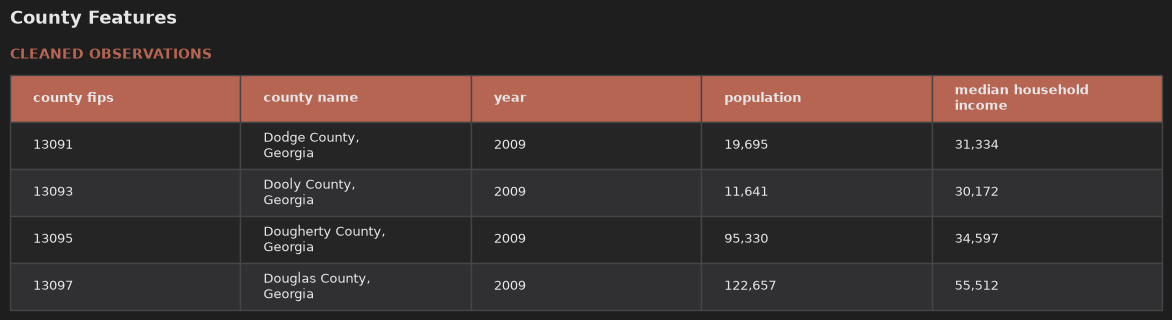

,origin_fips,destination_fips,year,individuals
0,53033,02013,2009,21.0
1,06073,02013,2009,17.0
2,06037,02013,2009,21.0
3,02020,02016,2009,48.0


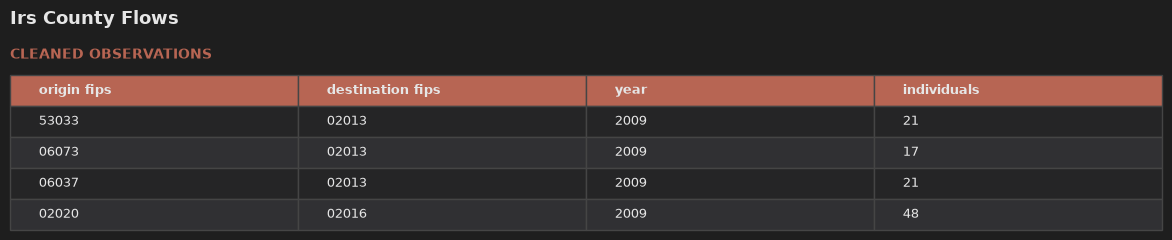

,county_fips,year,declarations,incident_types
0,01001,2009,1,1
1,01001,2011,2,1
2,01001,2015,1,1
3,01001,2017,3,1


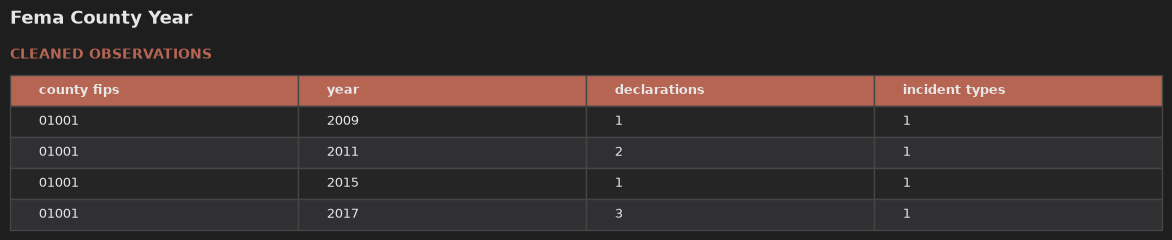

,county_fips,year,temperature_f,precipitation_inches
0,01001,2009,63.775000,73.20
1,01001,2010,63.591667,45.90
2,01001,2011,64.658333,45.23
3,01001,2012,65.658333,54.04


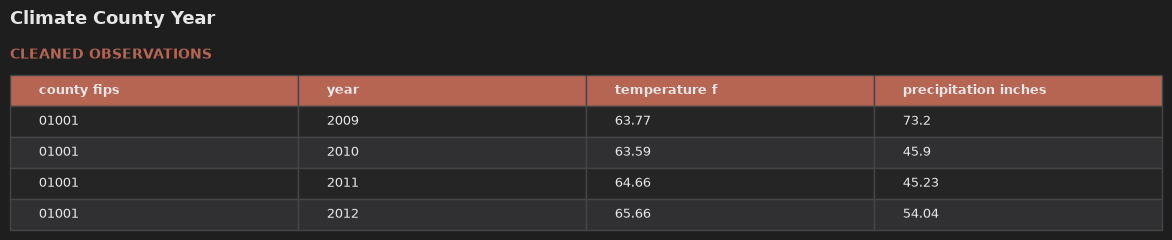

,county_fips,county_name,year,population,median_household_income
0,02000,Alaska,2009,683142.0,64635.0
1,09000,Connecticut,2009,3494487.0,67721.0
2,02000,Alaska,2010,691189.0,66521.0
3,09000,Connecticut,2010,3545837.0,67740.0


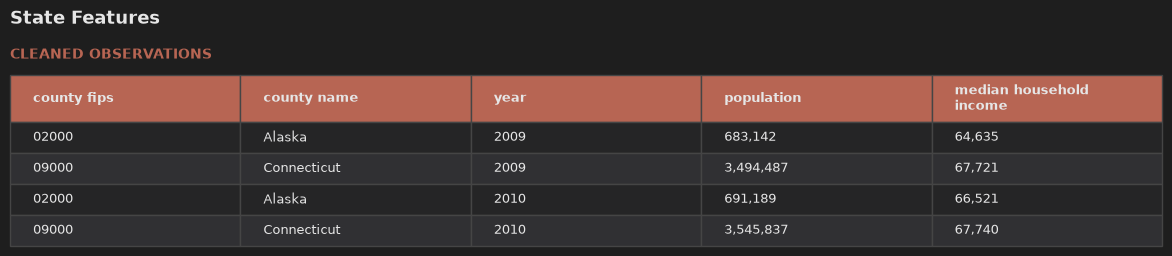

In [213]:
for name,columns in {
 'county_features':['county_fips','county_name','year','population','median_household_income'],
 'irs_county_flows':['origin_fips','destination_fips','year','individuals'],
 'fema_county_year':['county_fips','year','declarations','incident_types'],
 'climate_county_year':['county_fips','year','temperature_f','precipitation_inches'],
 'state_features':['county_fips','county_name','year','population','median_household_income']}.items():
    sample=pd.read_parquet(DATA/(name+'.parquet'),columns=columns).head(4)
    display(sample);table_image([sample],['CLEANED OBSERVATIONS'],name.replace('_',' ').title(),name+'_examples.png')


## 8. Check missingness, invalid values and suspect extremes before selecting records

Search for NA/NaN, blank/literal missing markers, infinities, duplicate keys, invalid identifiers/years, impossible percentages, invalid counts, implausible age/climate values and inconsistent migration arithmetic. Washington County, Kansas 2012 remains excluded: its anomalous outflow has no reliable replacement. Statistical extremes alone are retained and flagged; no unverified winsorization or invented corrections.

### 8.1. Recover identifiable geography and inspect the joined panel

Begin with unique same-year reference matches to recover identifiers when possible. Flag unresolved geography rather than guessing codes, then profile the joined measurements before defining exclusions.


In [214]:
def repair_identifiers(panel, reference):
    """Identifiers are recovered by unique same-year names, never statistical imputation."""
    result=panel.copy()
    ref=reference[['county_name','year','county_fips']].drop_duplicates()
    ref=ref.loc[~ref.duplicated(['county_name','year'],keep=False)]
    names=ref.set_index(['county_name','year']).county_fips
    known=set(reference.county_fips.dropna())
    missing=~result.county_fips.isin(known)
    result['identifier_repaired']=False
    for index in result.index[missing]:
        key=(result.at[index,'county_name'],result.at[index,'year'])
        if key in names:
            result.at[index,'county_fips']=names.loc[key]
            result.at[index,'identifier_repaired']=True
    valid_pairs=set(zip(reference.county_fips,reference.year))
    unresolved=pd.Series([(f,y) not in valid_pairs for f,y in zip(result.county_fips,result.year)],index=result.index)
    result['geography_caution']=result.get('geography_caution',pd.Series(False,index=result.index)) | unresolved
    return result

In [215]:
reference=pd.concat([acs,states],ignore_index=True)
panel=repair_identifiers(panel,reference)
display(profile(panel,MEASURES)[['variable','dtype','missing','missing_pct','minimum','median','maximum','iqr_outliers']])

,variable,dtype,missing,missing_pct,minimum,median,maximum,iqr_outliers
0,population,float64,0,0.000000,33.000000,25899.000000,1.010572e+07,6726
1,median_age,float64,0,0.000000,21.400000,40.900000,8.620000e+01,1587
2,median_household_income,float64,8,0.016091,17109.000000,49055.000000,1.817650e+05,1643
3,median_home_value,float64,39,0.078444,16800.000000,124400.000000,1.633900e+06,3283
4,median_gross_rent,float64,57,0.114649,99.000000,692.000000,2.922000e+03,2579
5,poverty_pct,float64,1,0.002011,0.000000,14.679565,5.902471e+01,1199
6,unemployment_pct,float64,6217,12.504777,0.000000,5.899543,3.241667e+01,1095
7,vacancy_pct,float64,0,0.000000,1.683968,15.172499,8.825911e+01,2263
8,homeownership_pct,float64,0,0.000000,0.000000,73.577933,9.738527e+01,1534
9,bachelors_plus_pct,float64,9324,18.754148,0.000000,19.418541,8.053254e+01,1833


### 8.2. Define explicit quality and exclusion rules

Use the preceding profile to inspect missingness and suspect values. Each Boolean mask records one reason a row cannot enter the final dataset; the same rules will be applied after imputation and checked again on retained records.


In [216]:
def cohort_reasons(panel):
    """Boolean reason flags; separate missingness, invalidity, and analysis restrictions."""
    required = IDENTIFIERS + MEASURES + ['geography_caution']
    missing_columns = set(required) - set(panel)
    if missing_columns:
        raise ValueError('Required panel columns missing: ' + ', '.join(sorted(missing_columns)))
    values = panel[MEASURES].apply(pd.to_numeric, errors='coerce').astype(float)
    flags = pd.DataFrame(index=panel.index)
    flags['missing_required_value'] = panel[required].isna().any(axis=1) | values.isna().any(axis=1)
    text=panel[IDENTIFIERS].select_dtypes(include=['object','string']).astype('string')
    flags['literal_missing_marker']=text.apply(lambda s:s.str.strip().str.lower().isin(['na','n/a','nan','none','null','<na>','missing'])).any(axis=1)
    flags['blank_identifier'] = panel[['county_fips','county_name']].apply(lambda s: s.astype('string').str.strip().eq('').fillna(False)).any(axis=1)
    flags['malformed_fips'] = ~panel.county_fips.astype('string').str.fullmatch(r'\d{5}').fillna(False)
    state_unit=panel.county_fips.isin(['02000','09000']) & panel.get('geography_level',pd.Series('county',index=panel.index)).eq('state')
    flags['outside_us_county_scope'] = ~panel.county_fips.astype('string').str[:2].isin(US_STATES) | (panel.county_fips.astype('string').str[2:].eq('000') & ~state_unit)
    year=pd.to_numeric(panel.year,errors='coerce')
    flags['invalid_year'] = ~np.isfinite(year) | year.lt(2009) | year.gt(datetime.now().year) | year.mod(1).ne(0)
    flags['duplicate_county_year'] = panel.duplicated(KEYS, keep=False)
    flags['nonfinite_numeric'] = np.isinf(values.to_numpy()).any(axis=1)
    flags['nonpositive_denominator_or_median'] = values[POSITIVE].le(0).any(axis=1)
    flags['percentage_outside_0_100'] = (values[PERCENTAGES].lt(0) | values[PERCENTAGES].gt(100)).any(axis=1)
    count_cols = ['population', 'inflow_individuals', 'outflow_individuals', 'declarations']
    flags['invalid_count'] = (values[count_cols].lt(0) | values[count_cols].mod(1).gt(1e-8)).any(axis=1)
    flags['invalid_age_or_climate'] = (values.median_age.le(0) | values.median_age.gt(100)
        | values.temperature_f.lt(-60) | values.temperature_f.gt(130)
        | values.precipitation_inches.lt(0) | values.precipitation_inches.gt(1000))
    flags['inconsistent_net_migration'] = (values.net_individuals - (values.inflow_individuals - values.outflow_individuals)).abs().gt(1e-6)
    rate_error = pd.DataFrame(index=panel.index)
    for stem in ['inflow_individuals','outflow_individuals','net_individuals']:
        expected = 1000 * values[stem] / values.population.where(values.population.gt(0))
        rate_error[stem] = (expected - values[stem+'_per_1000']).abs().gt(1e-6)
    flags['inconsistent_rate'] = rate_error.any(axis=1)
    # This is an explicit analysis restriction, NOT proof the published flow is incorrect.
    flags['rate_denominator_review'] = values[['inflow_individuals_per_1000','outflow_individuals_per_1000']].gt(1000).any(axis=1)
    flags['geography_review'] = panel.geography_caution.fillna(True).astype(bool)
    return flags.fillna(False).astype(bool)

### 8.3. Define the final validation checks

Turn the rules into assertions that stop execution if a final table contains missing or nonfinite values, duplicate keys, blank identifiers or other documented violations. This cell defines the check; section 9 executes it on the completed data.


In [217]:
def assert_clean_cohort(clean):
    if clean.empty:
        raise ValueError('No records passed the documented analysis rules')
    assert not clean.isna().any().any(), 'Final analysis table has missing values'
    assert not clean.duplicated(KEYS).any(), 'Duplicate analysis keys'
    assert np.isfinite(clean.select_dtypes(include='number').to_numpy()).all(), 'Nonfinite values'
    assert not clean.select_dtypes(include=['object','string']).apply(lambda x: x.astype('string').str.strip().eq('')).any().any(), 'Blank strings'
    check = clean.assign(geography_caution=False)
    assert not cohort_reasons(check).any().any(), 'Analysis table violates its validation rules'

### 8.4. Define record selection and interpretable transformations

Define how to record exclusions and enrich accepted rows after section 9 performs imputation. Education bands refer to adults aged 25+ with a bachelor's degree or higher; log population supplements the original measure. Retain and flag ordinary IQR extremes.


In [218]:
def build_analysis_cohort(panel):
    """Validate the prepared, imputed panel; record remaining exclusions and add transformations."""
    reasons = cohort_reasons(panel)
    accepted = ~reasons.any(axis=1)
    annotations=[c for c in panel if c.endswith('_imputed') or c in ['geography_level','data_split','identifier_repaired']]
    clean = panel.loc[accepted, IDENTIFIERS + MEASURES + annotations].copy()
    clean[MEASURES] = clean[MEASURES].astype(float)
    clean['year'] = pd.to_numeric(clean.year).astype(int)
    clean['log10_population'] = np.log10(clean.population)
    clean['education_band'] = pd.cut(clean.bachelors_plus_pct, [-np.inf,20,30,40,np.inf],
        labels=['Under 20%', '20 to <30%', '30 to <40%', '40% or more'], right=False).astype('string')
    clean['population_band'] = pd.cut(clean.population, [0,10000,50000,250000,np.inf],
        labels=['Under 10,000', '10,000 to <50,000', '50,000 to <250,000', '250,000 or more'], right=False).astype('string')
    clean['migration_balance'] = np.select([clean.net_individuals_per_1000.lt(-1),clean.net_individuals_per_1000.gt(1)],
        ['Net loss','Net gain'],default='Near balance')
    # Keep statistical outliers, label them for review, and do not confuse them with errors.
    grouped = clean.groupby('year').net_individuals_per_1000
    q1 = grouped.transform(lambda x: x.quantile(.25))
    q3 = grouped.transform(lambda x: x.quantile(.75))
    clean['net_rate_iqr_flag'] = clean.net_individuals_per_1000.lt(q1-1.5*(q3-q1)) | clean.net_individuals_per_1000.gt(q3+1.5*(q3-q1))
    exclusions = panel.loc[~accepted, IDENTIFIERS].copy()
    exclusions['reason'] = pd.Series(
        ['; '.join(row.index[row]) for _,row in reasons.loc[~accepted].iterrows()],
        index=exclusions.index,dtype='string')
    counts = pd.DataFrame({'rule':reasons.columns,'flagged_rows':reasons.sum().values})
    assert_clean_cohort(clean)
    return clean.reset_index(drop=True), exclusions.reset_index(drop=True), counts, reasons

### 8.5. Diagnose rule violations before imputation

Apply the masks to the current panel to show remaining problems.


In [219]:
# Diagnose the input before imputation; this is not a separate cleaned dataset.
initial_reasons=cohort_reasons(panel)
display(initial_reasons.sum().rename('flagged_before_imputation').to_frame())
display(panel.loc[initial_reasons.rate_denominator_review,['county_fips','county_name','year','population','outflow_individuals','outflow_individuals_per_1000']])


,flagged_before_imputation
missing_required_value,13001
literal_missing_marker,0
blank_identifier,0
malformed_fips,0
outside_us_county_scope,0
invalid_year,0
duplicate_county_year,0
nonfinite_numeric,0
nonpositive_denominator_or_median,0
percentage_outside_0_100,0


,county_fips,county_name,year,population,outflow_individuals,outflow_individuals_per_1000
11427,20201,"Washington County, Kansas",2012,5806.0,17139.0,2951.946262


### 8.6. Define the final missing-marker audit

Add an all-column scan for NA/NaN, literal missing markers, infinities and duplicate keys. Section 9 uses this alongside the substantive validation rules before publishing the dataset.


In [220]:
def quality_scan(frame,keys):
    text=frame.select_dtypes(include=['object','string']).astype('string')
    markers=text.apply(lambda s:s.str.strip().str.lower().isin(['','na','n/a','nan','none','null','<na>','missing']))
    return {'rows':len(frame),'na_nan':int(frame.isna().sum().sum()),
            'blank_or_literal_missing':int(markers.sum().sum()),
            'infinite':int(np.isinf(frame.select_dtypes(include='number')).sum().sum()),
            'duplicate_keys':int(frame.duplicated(keys).sum())}

def assert_complete(frame,keys):
    report=quality_scan(frame,keys)
    assert report['rows']>0
    assert all(value==0 for key,value in report.items() if key!='rows'),report
    return report

## 9. Impute socioeconomic features and publish the downstream dataset

Fit state medians, with training-wide fallback, using 2009 to 2018 only. Validation is 2019 to 2020 and testing is 2021 to 2023; refit if changing the split. Preserve the approved imputations and their flags, then recalculate derived variables and apply the final quality checks. The following variables are not imputed: Migration outcomes, population denominators or climate.

`analysis_county_year.parquet` and `.csv` are the single cleaned dataset for downstream analysis, including notebook 02. Source and intermediate audit tables remain available for tracing decisions; no separate observed-only cleaned version is exported.


### 9.1. Define recalculation from base quantities

Before filling any values, define how derived percentages and migration rates are recomputed from their underlying counts and denominators. The imputer below calls this function after filling missing socioeconomic inputs.


In [221]:
def recalculate(frame):
    frame = frame.copy()
    ratios = {'poverty_pct':('below_poverty','poverty_universe'),
              'unemployment_pct':('unemployed','civilian_labor_force'),
              'vacancy_pct':('vacant_units','housing_units'),
              'homeownership_pct':('owner_occupied_units','occupied_units')}
    for name,(num,den) in ratios.items():
        frame[name] = 100*frame[num]/frame[den].where(frame[den]>0)
    degree=['bachelors','masters','professional_degree','doctorate']
    frame['bachelors_plus_pct']=100*frame[degree].sum(axis=1,min_count=4)/frame.population_25_plus.where(frame.population_25_plus>0)
    if 'inflow_individuals' in frame:
        frame['net_individuals']=frame.inflow_individuals-frame.outflow_individuals
        for stem in ['inflow_individuals','outflow_individuals','net_individuals']:
            frame[stem+'_per_1000']=1000*frame[stem]/frame.population.where(frame.population>0)
    return frame

### 9.2. Define training-only imputation and its flags

Define the fit and transform operations separately: estimate state medians with a training-wide fallback, then reuse those estimates across all splits. Population-normalized demographic counts are scaled to observed population. Bound only imputed counts by their universes and flag every estimate.


In [222]:
class SocioeconomicImputer:
    """Train-only state medians of levels and population-normalized base counts."""
    levels=['median_age','median_household_income','median_home_value','median_gross_rent']
    counts=[v for v in ACS_VARIABLES.values() if v not in ['population','median_age','median_household_income','median_home_value','median_gross_rent']]

    def fit(self, panel, train_end=TRAIN_END):
        train=panel.loc[panel.year.le(train_end)&panel.population.gt(0)].copy()
        if train.empty:raise ValueError('No training observations for imputation')
        self.train_end=train_end;self.stats={}
        for col in self.levels+self.counts:
            values=pd.to_numeric(train[col],errors='coerce').replace([np.inf,-np.inf],np.nan)
            values=values.where(values.gt(0) if col in self.levels else values.ge(0))
            if col in self.counts:values=values/train.population
            self.stats[col]={'state':values.groupby(train.county_fips.str[:2]).median().dropna().to_dict(),
                             'global':float(values.median())}
            if not np.isfinite(self.stats[col]['global']):raise ValueError('No training values for '+col)
        return self

    def transform(self, panel):
        result=panel.copy();audit=[]
        for col,stats in self.stats.items():
            values=pd.to_numeric(result[col],errors='coerce').replace([np.inf,-np.inf],np.nan)
            missing=values.isna() # Invalid observed values still fail the exclusion rules.
            estimate=result.county_fips.str[:2].map(stats['state']).fillna(stats['global'])
            if col in self.counts:estimate=(estimate*result.population).round()
            result[col]=values.where(~missing,estimate)
            result[col+'_imputed']=missing & result[col].notna()
            audit.append({'variable':col,'imputed_rows':int(result[col+'_imputed'].sum())})
        # Constrain imputed counts to their observed/estimated universes, never change observed counts.
        for num,den in [('below_poverty','poverty_universe'),('unemployed','civilian_labor_force'),
                        ('vacant_units','housing_units'),('occupied_units','housing_units'),
                        ('owner_occupied_units','occupied_units')]:
            mask=result[num+'_imputed']&result[num].gt(result[den])
            result.loc[mask,num]=result.loc[mask,den]
        degree=['bachelors','masters','professional_degree','doctorate']
        total=result[degree].sum(axis=1,min_count=4)
        excess=total.gt(result.population_25_plus)
        for index in result.index[excess]:
            imputed=[c for c in degree if result.at[index,c+'_imputed']]
            observed=sum(result.at[index,c] for c in degree if c not in imputed)
            allowance=max(0,result.at[index,'population_25_plus']-observed)
            denom=sum(result.at[index,c] for c in imputed)
            for col in imputed:
                result.at[index,col]=np.floor(result.at[index,col]*allowance/denom) if denom else 0
        result=recalculate(result)
        result['socioeconomic_imputed']=result[[c+'_imputed' for c in self.stats]].any(axis=1)
        result['data_split']=np.select([result.year.le(self.train_end),result.year.le(VALIDATION_END)],['train','validation'],default='test')
        return result,pd.DataFrame(audit)

### 9.3. Fit, impute, recalculate and apply the selection rules

Fit only on training rows, transform the full panel and verify that migration outcomes are unchanged. Save donor statistics and imputation flags, then apply the section 8 rules and write the remaining exclusions.


In [223]:
imputer=SocioeconomicImputer().fit(panel,train_end=2018)
prepared,imputation_audit=imputer.transform(panel)
for variable in ['inflow_individuals','outflow_individuals']:
    pd.testing.assert_series_equal(panel[variable],prepared[variable])
display(imputation_audit)
display(prepared.groupby('data_split').agg(observations=('year','size'),imputed_observations=('socioeconomic_imputed','sum')))
imputation_audit.to_csv(TABLES/'socioeconomic_imputation.csv',index=False)
(DATA/'socioeconomic_imputer.json').write_text(json.dumps({'training_end':imputer.train_end,'validation_end':2020,'test_years':[2021,2022,2023],'statistics':imputer.stats},indent=2))
prepared.to_parquet(DATA/'prepared_geography_year.parquet',index=False)
clean,exclusions,rule_counts,reasons=build_analysis_cohort(prepared)
display(rule_counts)
print(f'Input {len(prepared):,}; accepted {len(clean):,}; excluded {len(exclusions):,}. Rules may overlap.')
rule_counts.to_csv(TABLES/'cleaning_rule_counts.csv',index=False)


,variable,imputed_rows
0,median_age,0
1,median_household_income,8
2,median_home_value,39
3,median_gross_rent,57
4,poverty_universe,1
5,below_poverty,1
6,civilian_labor_force,6217
7,unemployed,6217
8,housing_units,0
9,vacant_units,0


,observations,imputed_observations
data_split,,
test,12428,45
train,31075,9343
validation,6214,19


,rule,flagged_rows
0,missing_required_value,3689
1,literal_missing_marker,0
2,blank_identifier,0
3,malformed_fips,0
4,outside_us_county_scope,0
5,invalid_year,0
6,duplicate_county_year,0
7,nonfinite_numeric,0
8,nonpositive_denominator_or_median,0
9,percentage_outside_0_100,0


Input 49,717; accepted 46,027; excluded 3,690. Rules may overlap.


In [224]:
exclusions.to_csv(DATA/'analysis_exclusions.csv',index=False)
review=prepared.loc[reasons.rate_denominator_review,['county_fips','county_name','year','population','outflow_individuals','outflow_individuals_per_1000']]
display(review)
review.to_csv(TABLES/'extreme_rate_review.csv',index=False)
display(clean.groupby(['geography_level','data_split']).size().rename('accepted_observations').to_frame())


,county_fips,county_name,year,population,outflow_individuals,outflow_individuals_per_1000
11427,20201,"Washington County, Kansas",2012,5806.0,17139.0,2951.946262


accepted_observations
geography_level data_split                       
county          test                         9154
                train                       30749
                validation                   6094
state           test                            6
                train                          20
                validation                      4

### 9.4. Inspect transformations and quantify retention

Review example final records, including education bands and imputation flags. Summarize accepted and excluded rows by year and state so the effect of cleaning is visible before export.


In [225]:
display(clean[['county_name','geography_level','year','bachelors_plus_pct','education_band','population','log10_population','socioeconomic_imputed']].head(8))
retention=prepared.groupby('year').size().rename('input_rows').to_frame().join(clean.groupby('year').size().rename('accepted_rows')).fillna(0)
retention['excluded_rows']=retention.input_rows-retention.accepted_rows
retention['retained_pct']=100*retention.accepted_rows/retention.input_rows
display(retention);retention.to_csv(TABLES/'cleaning_retention_by_year.csv')
state_retention=prepared.assign(state=prepared.county_fips.str[:2]).groupby('state').size().rename('input_rows').to_frame().join(
    clean.assign(state=clean.county_fips.str[:2]).groupby('state').size().rename('accepted_rows')).fillna(0)
state_retention['retained_pct']=100*state_retention.accepted_rows/state_retention.input_rows
state_retention.to_csv(TABLES/'cleaning_retention_by_state.csv')

,county_name,geography_level,year,bachelors_plus_pct,education_band,population,log10_population,socioeconomic_imputed
0,"Dodge County, Georgia",county,2009,14.815944,Under 20%,19695.0,4.294356,True
1,"Dooly County, Georgia",county,2009,14.816248,Under 20%,11641.0,4.065990,True
2,"Dougherty County, Georgia",county,2009,14.810033,Under 20%,95330.0,4.979230,True
3,"Douglas County, Georgia",county,2009,14.809829,Under 20%,122657.0,5.088692,True
4,"Early County, Georgia",county,2009,14.804931,Under 20%,11812.0,4.072323,True
5,"Echols County, Georgia",county,2009,14.806789,Under 20%,4157.0,3.618780,True
6,"Effingham County, Georgia",county,2009,14.808191,Under 20%,50357.0,4.702060,True
7,"Elbert County, Georgia",county,2009,14.809951,Under 20%,20574.0,4.313319,True


,input_rows,accepted_rows,excluded_rows,retained_pct
year,,,,
2009,3108,3091.0,17.0,99.453024
2010,3108,3095.0,13.0,99.581725
2011,3108,3100.0,8.0,99.742600
2012,3108,3097.0,11.0,99.646075
2013,3108,3094.0,14.0,99.549550
2014,3107,3065.0,42.0,98.648214
2015,3107,3035.0,72.0,97.682652
2016,3107,3059.0,48.0,98.455101
2017,3107,3071.0,36.0,98.841326


### 9.5. Validate and publish the downstream dataset

Run the final assertions and all-column missing-marker audit. Save the summary, CSV and Parquet dataset, then record validation counts, retained years and imputation information in the cleaning manifest.


In [226]:
assert_clean_cohort(clean)
quality=pd.DataFrame({'analysis_county_year':assert_complete(clean,KEYS)}).T
display(quality)
quality.to_csv(TABLES/'analysis_data_quality.csv')
summary=profile(clean)
assert summary.missing.sum()==0
display(summary[['variable','dtype','missing','unique','minimum','median','maximum']])
summary.to_csv(TABLES/'analysis_data_summary.csv',index=False)
clean.to_parquet(DATA/'analysis_county_year.parquet',index=False)
clean.to_csv(DATA/'analysis_county_year.csv',index=False)


,rows,na_nan,blank_or_literal_missing,infinite,duplicate_keys
analysis_county_year,46027,0,0,0,0


,variable,dtype,missing,unique,minimum,median,maximum
0,county_fips,object,0,3103,NaN,NaN,NaN
1,county_name,str,0,3105,NaN,NaN,NaN
2,year,int64,0,15,2009.000000,2016.000000,2.023000e+03
3,population,float64,0,35971,241.000000,26432.000000,1.010572e+07
4,median_age,float64,0,405,21.400000,40.800000,6.840000e+01
5,median_household_income,float64,0,29101,17109.000000,48138.000000,1.787070e+05
6,median_home_value,float64,0,4389,18700.000000,122000.000000,1.494500e+06
7,median_gross_rent,float64,0,1612,99.000000,683.000000,2.893000e+03
8,poverty_pct,float64,0,45878,0.000000,14.819444,5.902471e+01
9,unemployment_pct,float64,0,45108,0.000000,6.358790,3.241667e+01


In [227]:
record={'input_panel_sha256':hashlib.sha256((DATA/'county_year_panel.parquet').read_bytes()).hexdigest(),
 'input_rows':len(prepared),'analysis_rows':len(clean),'excluded_rows':len(exclusions),
 'analysis_years':sorted(clean.year.unique().tolist()),'columns':clean.columns.tolist(),
 'missing_values':int(clean.isna().sum().sum()),'duplicate_keys':int(clean.duplicated(['county_fips','year']).sum()),
 'infinite_values':int(np.isinf(clean.select_dtypes(include='number')).sum().sum()),
 'retained_iqr_flags':int(clean.net_rate_iqr_flag.sum()),'rule_counts':rule_counts.to_dict('records'),
 'training_end':2018,'validation_end':2020,'imputed_observations':int(clean.socioeconomic_imputed.sum()),
 'geography_units':clean.geography_level.value_counts().to_dict()}
(DATA/'analysis_cleaning_manifest.json').write_text(json.dumps(record,indent=2))
print(f"Validated {len(clean):,} geography-years with no missing values, infinities or duplicate keys.")


Validated 46,027 geography-years with no missing values, infinities or duplicate keys.


Use `data/processed/analysis_county_year.parquet` or `.csv` for downstream analysis. Imputation flags identify estimated features and observations. All exclusions are recorded in `analysis_exclusions.csv`; quality and retention reports accompany the export.
